# 🌍 StudyAbroad AI
## Personalized AI-Powered Study Abroad Guidance System

### Project Objective
StudyAbroad AI is an intelligent system designed to help students plan their international education journey. The system analyzes a student's academic profile, budget, preferred course, career goals, and country preferences to provide personalized country and university recommendations.

### Core Features
- Student Profile Analysis
- Country Recommendation
- University Recommendation
- Scholarship Recommendation
- AI-Powered SOP Generator
- Personalized Application Roadmap
- RAG-Based Study Abroad Chatbot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/StudyAbroad_AI"

folders = [
    "data",
    "knowledge_base",
    "models",
    "outputs"
]

os.makedirs(project_path, exist_ok=True)

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully!")
print("\nProject Path:", project_path)

print("\nFolders:")
for folder in folders:
    print("📁", folder)

Project folders created successfully!

Project Path: /content/drive/MyDrive/StudyAbroad_AI

Folders:
📁 data
📁 knowledge_base
📁 models
📁 outputs


In [ ]:
!pip install pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
print("========== STUDYABROAD AI PROJECT ==========")
print("Project Name: StudyAbroad AI")
print("Environment: Google Colab")
print("Storage: Google Drive")
print("Status: Setup Completed ✅")
print("============================================")

========== STUDYABROAD AI PROJECT ==========
Project Name: StudyAbroad AI
Environment: Google Colab
Storage: Google Drive
Status: Setup Completed ✅


In [ ]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
cost_path = "/content/International_Education_Costs.csv"

qs_path = "/content/QS World University Rankings 2025 (Top global universities).csv"

academic_path = "/content/academic.csv"

scholarship_path = "/content/international_scholarships_cleaned.csv"

print("Dataset paths defined successfully!")

Dataset paths defined successfully!


In [ ]:
try:
    cost_df = pd.read_csv(cost_path)
    print("✅ International Education Cost dataset loaded")

    qs_df = pd.read_csv(qs_path, encoding='latin1')
    print("✅ QS World University Rankings dataset loaded")

    academic_df = pd.read_csv(academic_path, encoding='latin1')
    print("✅ Academic dataset loaded")

    scholarship_df = pd.read_csv(scholarship_path, encoding='latin1')
    print("✅ International Scholarships dataset loaded")

except Exception as e:
    print("Error loading dataset:", e)

✅ International Education Cost dataset loaded
✅ QS World University Rankings dataset loaded
✅ Academic dataset loaded
✅ International Scholarships dataset loaded


In [ ]:
datasets = {}

if 'cost_df' in locals() and isinstance(cost_df, pd.DataFrame):
    datasets["International Education Costs"] = cost_df
if 'qs_df' in locals() and isinstance(qs_df, pd.DataFrame):
    datasets["QS World University Rankings"] = qs_df
if 'academic_df' in locals() and isinstance(academic_df, pd.DataFrame):
    datasets["Academic Dataset"] = academic_df
if 'scholarship_df' in locals() and isinstance(scholarship_df, pd.DataFrame):
    datasets["International Scholarships"] = scholarship_df

summary_data = []

for name, df in datasets.items():
    summary_data.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary_data)

print("========== DATASET AUDIT SUMMARY ==========")
display(summary_df)

========== DATASET AUDIT SUMMARY ==========


,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,International Education Costs,907,12,0,0
1,QS World University Rankings,1503,28,1316,0
2,Academic Dataset,77,7,117,0
3,International Scholarships,10410,7,0,0


In [ ]:
for name, df in datasets.items():
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)

    print("\nColumns:")
    for i, column in enumerate(df.columns, start=1):
        print(f"{i}. {column}")


DATASET: International Education Costs

Columns:
1. Country
2. City
3. University
4. Program
5. Level
6. Duration_Years
7. Tuition_USD
8. Living_Cost_Index
9. Rent_USD
10. Visa_Fee_USD
11. Insurance_USD
12. Exchange_Rate

DATASET: QS World University Rankings

Columns:
1. RANK_2025
2. RANK_2024
3. Institution_Name
4. Location
5. Region
6. SIZE
7. FOCUS
8. RES.
9. STATUS
10. Academic_Reputation_Score
11. Academic_Reputation_Rank
12. Employer_Reputation_Score
13. Employer_Reputation_Rank
14. Faculty_Student_Score
15. Faculty_Student_Rank
16. Citations_per_Faculty_Score
17. Citations_per_Faculty_Rank
18. International_Faculty_Score
19. International_Faculty_Rank
20. International_Students_Score
21. International_Students_Rank
22. International_Research_Network_Score
23. International_Research_Network_Rank
24. Employment_Outcomes_Score
25. Employment_Outcomes_Rank
26. Sustainability_Score
27. Sustainability_Rank
28. Overall_Score

DATASET: Academic Dataset

Columns:
1. year
2. students
3.

In [ ]:
for name, df in datasets.items():

    print("\n" + "="*80)
    print(f"FIRST 5 RECORDS: {name}")
    print("="*80)

    display(df.head())


FIRST 5 RECORDS: International Education Costs


,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92



FIRST 5 RECORDS: QS World University Rankings


,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,4,100.0,2,100.0,11,100.0,9,99.3,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,2,100.0,5,100.0,8,84.8,93,98.1,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,3,100.0,4,100.0,17,84.6,96,100.0,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7



FIRST 5 RECORDS: Academic Dataset


,year,students,us_students,undergraduate,graduate,non_degree,opt
0,1948/49,25464.0,2403400.0,NaN,NaN,NaN,NaN
1,1949/50,26433.0,2445000.0,NaN,NaN,NaN,NaN
2,1950/51,29813.0,2281000.0,NaN,NaN,NaN,NaN
3,1951/52,30462.0,2102000.0,NaN,NaN,NaN,NaN
4,1952/53,33675.0,2134000.0,NaN,NaN,NaN,NaN



FIRST 5 RECORDS: International Scholarships


,Scholarship Name,Deadline,Amount,Description,Location,Years,Link
0,Order Sons of Italy in America National Leader...,Unknown deadline,500.0,Applicant must be of Italian heritage and be a...,No Geographic Restrictions,"['College junior', 'College freshman', 'Colleg...",https://www.collegescholarships.org/financial-...
1,Entrance Scholarship,Unknown deadline,500.0,Applicant must be an incoming first-year stude...,No Geographic Restrictions,['College freshman'],https://www.collegescholarships.org/financial-...
2,Agnes Jones Jackson Scholarship,Unknown deadline,500.0,Applicant must be current member of the NAACP ...,No Geographic Restrictions,"['College freshman', 'Master&#039;s-level stud...",https://www.collegescholarships.org/financial-...
3,Fellowship in Jewish Studies,Unknown deadline,500.0,Applicant must have an interest in Jewish stud...,No Geographic Restrictions,['High school senior'],https://www.collegescholarships.org/financial-...
4,Doctoral Scholarship,Unknown deadline,500.0,Applicant must be a doctoral student specializ...,No Geographic Restrictions,['Doctoral-level study'],https://www.collegescholarships.org/financial-...


In [ ]:
for name, df in datasets.items():

    print("\n" + "="*70)
    print(f"DATA TYPES: {name}")
    print("="*70)

    display(pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values
    }))


DATA TYPES: International Education Costs


,Column,Data Type
0,Country,object
1,City,object
2,University,object
3,Program,object
4,Level,object
5,Duration_Years,float64
6,Tuition_USD,int64
7,Living_Cost_Index,float64
8,Rent_USD,int64
9,Visa_Fee_USD,int64



DATA TYPES: QS World University Rankings


,Column,Data Type
0,RANK_2025,object
1,RANK_2024,object
2,Institution_Name,object
3,Location,object
4,Region,object
5,SIZE,object
6,FOCUS,object
7,RES.,object
8,STATUS,object
9,Academic_Reputation_Score,float64



DATA TYPES: Academic Dataset


,Column,Data Type
0,year,object
1,students,float64
2,us_students,float64
3,undergraduate,float64
4,graduate,float64
5,non_degree,float64
6,opt,float64



DATA TYPES: International Scholarships


,Column,Data Type
0,Scholarship Name,object
1,Deadline,object
2,Amount,float64
3,Description,object
4,Location,object
5,Years,object
6,Link,object


In [ ]:
for name, df in datasets.items():

    print("\n" + "="*70)
    print(f"MISSING VALUES: {name}")
    print("="*70)

    missing = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing Percentage": (
            df.isnull().sum().values / len(df) * 100
        ).round(2)
    })

    missing = missing[missing["Missing Values"] > 0]

    if len(missing) > 0:
        display(missing.sort_values(
            by="Missing Percentage",
            ascending=False
        ))
    else:
        print("✅ No missing values found!")


MISSING VALUES: International Education Costs
✅ No missing values found!

MISSING VALUES: QS World University Rankings


,Column,Missing Values,Missing Percentage
27,Overall_Score,902,60.01
18,International_Faculty_Rank,100,6.65
17,International_Faculty_Score,100,6.65
20,International_Students_Rank,58,3.86
19,International_Students_Score,58,3.86
8,STATUS,37,2.46
1,RANK_2024,21,1.40
26,Sustainability_Rank,19,1.26
25,Sustainability_Score,19,1.26
21,International_Research_Network_Score,1,0.07



MISSING VALUES: Academic Dataset


,Column,Missing Values,Missing Percentage
6,opt,31,40.26
5,non_degree,31,40.26
4,graduate,26,33.77
3,undergraduate,26,33.77
2,us_students,3,3.90



MISSING VALUES: International Scholarships
✅ No missing values found!


In [ ]:
for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(f"\n{name}")
    print(f"Duplicate Rows: {duplicate_count}")

    if duplicate_count == 0:
        print("Status: ✅ No duplicate rows")
    else:
        print("Status: ⚠️ Duplicates detected")


International Education Costs
Duplicate Rows: 0
Status: ✅ No duplicate rows

QS World University Rankings
Duplicate Rows: 0
Status: ✅ No duplicate rows

Academic Dataset
Duplicate Rows: 0
Status: ✅ No duplicate rows

International Scholarships
Duplicate Rows: 0
Status: ✅ No duplicate rows


In [ ]:
metadata = []

for name, df in datasets.items():

    metadata.append({
        "Dataset Name": name,
        "Number of Records": df.shape[0],
        "Number of Features": df.shape[1],
        "Total Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum(),
        "Memory Usage (MB)": round(
            df.memory_usage(deep=True).sum() / (1024**2),
            2
        )
    })

metadata_df = pd.DataFrame(metadata)

print("📊 FINAL DATASET METADATA REPORT")
display(metadata_df)

📊 FINAL DATASET METADATA REPORT


,Dataset Name,Number of Records,Number of Features,Total Missing Values,Duplicate Records,Memory Usage (MB)
0,International Education Costs,907,12,0,0,0.31
1,QS World University Rankings,1503,28,1316,0,1.57
2,Academic Dataset,77,7,117,0,0.01
3,International Scholarships,10410,7,0,0,6.87


In [ ]:
clean_data_path = os.path.join(project_path, "clean_data")

os.makedirs(clean_data_path, exist_ok=True)

print("✅ Clean data folder created:")
print(clean_data_path)

✅ Clean data folder created:
/content/drive/MyDrive/StudyAbroad_AI/clean_data


In [ ]:
import re

def clean_column_names(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^a-zA-Z0-9]+', '_', col.strip().lower()).strip('_')
        for col in df.columns
    ]

    return df

In [ ]:
def basic_cleaning(df):
    df = df.copy()

    # Clean column names
    df = clean_column_names(df)

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Clean string columns
    for column in df.select_dtypes(include="object").columns:
        df[column] = (
            df[column]
            .astype(str)
            .str.strip()
            .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        )

    return df

In [ ]:
if 'cost_df' in locals():
    cost_clean = basic_cleaning(cost_df)
else:
    print("⚠️ cost_df not found, skipping cleaning.")

if 'qs_df' in locals():
    qs_clean = basic_cleaning(qs_df)
else:
    print("⚠️ qs_df not found, skipping cleaning.")

if 'academic_df' in locals():
    academic_clean = basic_cleaning(academic_df)
else:
    print("⚠️ academic_df not found, skipping cleaning.")

if 'scholarship_df' in locals():
    scholarship_clean = basic_cleaning(scholarship_df)
else:
    print("⚠️ scholarship_df not found, skipping cleaning.")

print("✅ Basic cleaning attempted for all datasets!")

✅ Basic cleaning attempted for all datasets!


In [ ]:
comparison = pd.DataFrame({
    "Dataset": [
        "Education Cost",
        "QS Rankings",
        "Academic",
        "Scholarships"
    ],

    "Rows Before": [
        len(cost_df),
        len(qs_df),
        len(academic_df),
        len(scholarship_df)
    ],

    "Rows After": [
        len(cost_clean),
        len(qs_clean),
        len(academic_clean),
        len(scholarship_clean)
    ],

    "Duplicates Removed": [
        len(cost_df) - len(cost_clean),
        len(qs_df) - len(qs_clean),
        len(academic_df) - len(academic_clean),
        len(scholarship_df) - len(scholarship_clean)
    ]
})

display(comparison)

,Dataset,Rows Before,Rows After,Duplicates Removed
0,Education Cost,907,907,0
1,QS Rankings,1503,1503,0
2,Academic,77,77,0
3,Scholarships,10410,10410,0


In [ ]:
cleaned_datasets = {
    "Education Cost": cost_clean,
    "QS Rankings": qs_clean,
    "Academic": academic_clean,
    "Scholarships": scholarship_clean
}

for name, df in cleaned_datasets.items():

    print("\n" + "="*70)
    print(f"{name.upper()} CLEANED COLUMNS")
    print("="*70)

    print(list(df.columns))


EDUCATION COST CLEANED COLUMNS
['country', 'city', 'university', 'program', 'level', 'duration_years', 'tuition_usd', 'living_cost_index', 'rent_usd', 'visa_fee_usd', 'insurance_usd', 'exchange_rate']

QS RANKINGS CLEANED COLUMNS
['rank_2025', 'rank_2024', 'institution_name', 'location', 'region', 'size', 'focus', 'res', 'status', 'academic_reputation_score', 'academic_reputation_rank', 'employer_reputation_score', 'employer_reputation_rank', 'faculty_student_score', 'faculty_student_rank', 'citations_per_faculty_score', 'citations_per_faculty_rank', 'international_faculty_score', 'international_faculty_rank', 'international_students_score', 'international_students_rank', 'international_research_network_score', 'international_research_network_rank', 'employment_outcomes_score', 'employment_outcomes_rank', 'sustainability_score', 'sustainability_rank', 'overall_score']

ACADEMIC CLEANED COLUMNS
['year', 'students', 'us_students', 'undergraduate', 'graduate', 'non_degree', 'opt']

SCHOL

In [ ]:
for name, df in cleaned_datasets.items():

    print("\n" + "="*70)
    print(f"MISSING VALUE REPORT: {name}")
    print("="*70)

    missing_report = pd.DataFrame({
        "Column": df.columns,
        "Missing Count": df.isnull().sum(),
        "Missing %": (
            df.isnull().mean() * 100
        ).round(2)
    })

    display(
        missing_report[
            missing_report["Missing Count"] > 0
        ].sort_values(
            by="Missing %",
            ascending=False
        )
    )


MISSING VALUE REPORT: Education Cost


,Column,Missing Count,Missing %



MISSING VALUE REPORT: QS Rankings


,Column,Missing Count,Missing %
overall_score,overall_score,902,60.01
international_faculty_rank,international_faculty_rank,100,6.65
international_faculty_score,international_faculty_score,100,6.65
international_students_rank,international_students_rank,58,3.86
international_students_score,international_students_score,58,3.86
status,status,37,2.46
rank_2024,rank_2024,21,1.40
sustainability_rank,sustainability_rank,19,1.26
sustainability_score,sustainability_score,19,1.26
international_research_network_score,international_research_network_score,1,0.07



MISSING VALUE REPORT: Academic


,Column,Missing Count,Missing %
opt,opt,31,40.26
non_degree,non_degree,31,40.26
graduate,graduate,26,33.77
undergraduate,undergraduate,26,33.77
us_students,us_students,3,3.90



MISSING VALUE REPORT: Scholarships


,Column,Missing Count,Missing %


In [ ]:
country_mapping = {
    "usa": "United States",
    "us": "United States",
    "u.s.": "United States",
    "u.s.a.": "United States",
    "uk": "United Kingdom",
    "u.k.": "United Kingdom",
    "england": "United Kingdom"
}

def standardize_countries(df):
    df = df.copy()

    possible_columns = [
        "country",
        "country_name",
        "location",
        "country_region"
    ]

    for column in possible_columns:
        if column in df.columns:

            df[column] = (
                df[column]
                .astype(str)
                .str.strip()
                .replace("nan", np.nan)
            )

            df[column] = df[column].replace(
                {k: v for k, v in country_mapping.items()}
            )

    return df

In [ ]:
cost_clean = standardize_countries(cost_clean)
qs_clean = standardize_countries(qs_clean)
academic_clean = standardize_countries(academic_clean)
scholarship_clean = standardize_countries(scholarship_clean)

print("✅ Country standardization completed!")

✅ Country standardization completed!


In [ ]:
def dataset_quality_report(df, name):

    total_cells = df.shape[0] * df.shape[1]

    missing_cells = df.isnull().sum().sum()

    duplicate_rows = df.duplicated().sum()

    completeness = (
        (total_cells - missing_cells)
        / total_cells * 100
    )

    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Completeness %": round(completeness, 2),
        "Duplicate Rows": duplicate_rows
    }


quality_reports = []

quality_reports.append(
    dataset_quality_report(cost_clean, "Education Cost")
)

quality_reports.append(
    dataset_quality_report(qs_clean, "QS Rankings")
)

quality_reports.append(
    dataset_quality_report(academic_clean, "Academic")
)

quality_reports.append(
    dataset_quality_report(scholarship_clean, "Scholarships")
)

quality_df = pd.DataFrame(quality_reports)

print("📊 DATA QUALITY REPORT")
display(quality_df)

📊 DATA QUALITY REPORT


,Dataset,Rows,Columns,Completeness %,Duplicate Rows
0,Education Cost,907,12,100.00,0
1,QS Rankings,1503,28,96.87,0
2,Academic,77,7,78.29,0
3,Scholarships,10410,7,100.00,0


In [ ]:
cost_clean.to_csv(
    os.path.join(clean_data_path, "education_cost_clean.csv"),
    index=False
)

qs_clean.to_csv(
    os.path.join(clean_data_path, "qs_rankings_clean.csv"),
    index=False
)

academic_clean.to_csv(
    os.path.join(clean_data_path, "academic_clean.csv"),
    index=False
)

scholarship_clean.to_csv(
    os.path.join(clean_data_path, "scholarships_clean.csv"),
    index=False
)

print("✅ All cleaned datasets saved successfully!")

✅ All cleaned datasets saved successfully!


In [ ]:
import pandas as pd
import os

cost_clean = pd.read_csv(
    os.path.join(clean_data_path, "education_cost_clean.csv")
)

qs_clean = pd.read_csv(
    os.path.join(clean_data_path, "qs_rankings_clean.csv")
)

academic_clean = pd.read_csv(
    os.path.join(clean_data_path, "academic_clean.csv")
)

scholarship_clean = pd.read_csv(
    os.path.join(clean_data_path, "scholarships_clean.csv")
)

print("✅ All cleaned datasets loaded successfully!")

✅ All cleaned datasets loaded successfully!


In [ ]:
def inspect_schema(df, name):

    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    schema = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Non-Null Count": df.notnull().sum().values,
        "Unique Values": df.nunique().values
    })

    display(schema)

In [ ]:
inspect_schema(cost_clean, "EDUCATION COST DATASET")

inspect_schema(qs_clean, "QS RANKINGS DATASET")

inspect_schema(academic_clean, "ACADEMIC DATASET")

inspect_schema(scholarship_clean, "SCHOLARSHIP DATASET")

DATASET: EDUCATION COST DATASET


,Column,Data Type,Non-Null Count,Unique Values
0,country,object,907,71
1,city,object,907,556
2,university,object,907,622
3,program,object,907,92
4,level,object,907,3
5,duration_years,float64,907,7
6,tuition_usd,int64,907,274
7,living_cost_index,float64,907,225
8,rent_usd,int64,907,67
9,visa_fee_usd,int64,907,30


DATASET: QS RANKINGS DATASET


,Column,Data Type,Non-Null Count,Unique Values
0,rank_2025,object,1503,388
1,rank_2024,object,1482,378
2,institution_name,object,1503,1503
3,location,object,1503,106
4,region,object,1503,6
5,size,object,1503,4
6,focus,object,1503,4
7,res,object,1503,4
8,status,object,1466,3
9,academic_reputation_score,float64,1503,472


DATASET: ACADEMIC DATASET


,Column,Data Type,Non-Null Count,Unique Values
0,year,object,77,77
1,students,float64,77,77
2,us_students,float64,74,74
3,undergraduate,float64,51,51
4,graduate,float64,51,51
5,non_degree,float64,46,46
6,opt,float64,46,46


DATASET: SCHOLARSHIP DATASET


,Column,Data Type,Non-Null Count,Unique Values
0,scholarship_name,object,10410,9062
1,deadline,object,10410,1
2,amount,float64,10410,96
3,description,object,10410,8862
4,location,object,10410,695
5,years,object,10410,761
6,link,object,10410,10410


In [ ]:
dataset_roles = pd.DataFrame({
    "Dataset": [
        "QS Rankings",
        "International Education Costs",
        "Academic Dataset",
        "Scholarships"
    ],

    "Primary Role": [
        "University Ranking & Reputation",
        "Financial & Cost Analysis",
        "Academic/Student Intelligence",
        "Scholarship Matching"
    ],

    "Used For": [
        "University ranking recommendation",
        "Budget compatibility",
        "Student profile analysis",
        "Scholarship recommendation"
    ]
})

display(dataset_roles)

,Dataset,Primary Role,Used For
0,QS Rankings,University Ranking & Reputation,University ranking recommendation
1,International Education Costs,Financial & Cost Analysis,Budget compatibility
2,Academic Dataset,Academic/Student Intelligence,Student profile analysis
3,Scholarships,Scholarship Matching,Scholarship recommendation


In [ ]:
datasets_for_comparison = {
    "Cost": cost_clean,
    "QS": qs_clean,
    "Academic": academic_clean,
    "Scholarship": scholarship_clean
}

for name1, df1 in datasets_for_comparison.items():
    for name2, df2 in datasets_for_comparison.items():

        if name1 < name2:
            common_columns = set(df1.columns).intersection(
                set(df2.columns)
            )

            print(f"\n{name1} ↔ {name2}")
            print("Common Columns:", common_columns)


Cost ↔ QS
Common Columns: set()

Cost ↔ Scholarship
Common Columns: set()

QS ↔ Scholarship
Common Columns: {'location'}

Academic ↔ Cost
Common Columns: set()

Academic ↔ QS
Common Columns: set()

Academic ↔ Scholarship
Common Columns: set()


In [ ]:
for name, df in datasets_for_comparison.items():

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    for column in df.columns:
        print(f"• {column}")


COST
• country
• city
• university
• program
• level
• duration_years
• tuition_usd
• living_cost_index
• rent_usd
• visa_fee_usd
• insurance_usd
• exchange_rate

QS
• rank_2025
• rank_2024
• institution_name
• location
• region
• size
• focus
• res
• status
• academic_reputation_score
• academic_reputation_rank
• employer_reputation_score
• employer_reputation_rank
• faculty_student_score
• faculty_student_rank
• citations_per_faculty_score
• citations_per_faculty_rank
• international_faculty_score
• international_faculty_rank
• international_students_score
• international_students_rank
• international_research_network_score
• international_research_network_rank
• employment_outcomes_score
• employment_outcomes_rank
• sustainability_score
• sustainability_rank
• overall_score

ACADEMIC
• year
• students
• us_students
• undergraduate
• graduate
• non_degree
• opt

SCHOLARSHIP
• scholarship_name
• deadline
• amount
• description
• location
• years
• link


In [ ]:
import re

def normalize_university_name(name):

    if pd.isna(name):
        return np.nan

    name = str(name).lower()

    # Remove special characters
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    # Common replacements
    replacements = {
        "univ ": "university ",
        "univ.": "university",
        "inst ": "institute "
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    return name

In [ ]:
def find_possible_columns(df, keywords):

    matches = []

    for col in df.columns:
        for keyword in keywords:
            if keyword.lower() in col.lower():
                matches.append(col)
                break

    return matches


print("Possible University Columns:")

for name, df in datasets_for_comparison.items():

    matches = find_possible_columns(
        df,
        ["university", "institution", "school", "college"]
    )

    print(f"{name}: {matches}")

Possible University Columns:
Cost: ['university']
QS: ['institution_name']
Academic: []
Scholarship: []


In [ ]:
print("Possible Country Columns:")

for name, df in datasets_for_comparison.items():

    matches = find_possible_columns(
        df,
        ["country", "nation", "location"]
    )

    print(f"{name}: {matches}")

Possible Country Columns:
Cost: ['country']
QS: ['location', 'international_faculty_score', 'international_faculty_rank', 'international_students_score', 'international_students_rank', 'international_research_network_score', 'international_research_network_rank']
Academic: []
Scholarship: ['location']


In [ ]:
integration_report = []

for name, df in datasets_for_comparison.items():

    university_cols = find_possible_columns(
        df,
        ["university", "institution", "school", "college"]
    )

    country_cols = find_possible_columns(
        df,
        ["country", "nation"]
    )

    course_cols = find_possible_columns(
        df,
        ["course", "program", "subject", "field"]
    )

    integration_report.append({
        "Dataset": name,
        "Rows": len(df),
        "University Identifier": ", ".join(university_cols) if university_cols else "Not Found",
        "Country Identifier": ", ".join(country_cols) if country_cols else "Not Found",
        "Course Identifier": ", ".join(course_cols) if course_cols else "Not Found"
    })

integration_report_df = pd.DataFrame(integration_report)

print("📊 DATA INTEGRATION READINESS REPORT")
display(integration_report_df)

📊 DATA INTEGRATION READINESS REPORT


,Dataset,Rows,University Identifier,Country Identifier,Course Identifier
0,Cost,907,university,country,program
1,QS,1503,institution_name,"international_faculty_score, international_fac...",Not Found
2,Academic,77,Not Found,Not Found,Not Found
3,Scholarship,10410,Not Found,Not Found,Not Found


In [ ]:
integration_report_file = os.path.join(
    project_path,
    "outputs",
    "data_integration_readiness_report.csv"
)

integration_report_df.to_csv(
    integration_report_file,
    index=False
)

print("✅ Integration report saved successfully!")

✅ Integration report saved successfully!


In [ ]:
integration_path = os.path.join(project_path, "master_data")
os.makedirs(integration_path, exist_ok=True)

print("✅ Master data folder created!")

✅ Master data folder created!


In [ ]:
print("QS DATASET COLUMNS:")
print(list(qs_clean.columns))

print("\n" + "="*60)

print("COST DATASET COLUMNS:")
print(list(cost_clean.columns))

QS DATASET COLUMNS:
['rank_2025', 'rank_2024', 'institution_name', 'location', 'region', 'size', 'focus', 'res', 'status', 'academic_reputation_score', 'academic_reputation_rank', 'employer_reputation_score', 'employer_reputation_rank', 'faculty_student_score', 'faculty_student_rank', 'citations_per_faculty_score', 'citations_per_faculty_rank', 'international_faculty_score', 'international_faculty_rank', 'international_students_score', 'international_students_rank', 'international_research_network_score', 'international_research_network_rank', 'employment_outcomes_score', 'employment_outcomes_rank', 'sustainability_score', 'sustainability_rank', 'overall_score']

COST DATASET COLUMNS:
['country', 'city', 'university', 'program', 'level', 'duration_years', 'tuition_usd', 'living_cost_index', 'rent_usd', 'visa_fee_usd', 'insurance_usd', 'exchange_rate']


In [ ]:
def detect_column(columns, keywords):
    """
    Finds the first column containing one of the keywords.
    """
    for keyword in keywords:
        for col in columns:
            if keyword.lower() in col.lower():
                return col
    return None


qs_university_col = detect_column(
    qs_clean.columns,
    ["university", "institution", "university_name"]
)

cost_university_col = detect_column(
    cost_clean.columns,
    ["university", "institution", "university_name"]
)

print("QS University Column:", qs_university_col)
print("Cost University Column:", cost_university_col)

QS University Column: institution_name
Cost University Column: university


In [ ]:
import re
import pandas as pd
import numpy as np

def normalize_university_name(name):

    if pd.isna(name):
        return np.nan

    name = str(name).lower()

    # Remove punctuation
    name = re.sub(r'[^a-z0-9\s]', ' ', name)

    # Standard replacements
    replacements = {
        "univ": "university",
        "inst": "institute",
        "tech": "technology"
    }

    words = name.split()

    words = [
        replacements.get(word, word)
        for word in words
    ]

    name = " ".join(words)

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    return name

In [ ]:
qs_master = qs_clean.copy()
cost_master = cost_clean.copy()

qs_master["university_key"] = qs_master[
    qs_university_col
].apply(normalize_university_name)

cost_master["university_key"] = cost_master[
    cost_university_col
].apply(normalize_university_name)

print("✅ University matching keys created")

✅ University matching keys created


In [ ]:
qs_universities = set(
    qs_master["university_key"].dropna()
)

cost_universities = set(
    cost_master["university_key"].dropna()
)

common_universities = qs_universities.intersection(
    cost_universities
)

print("QS Universities:", len(qs_universities))
print("Cost Dataset Universities:", len(cost_universities))
print("Exact Matches:", len(common_universities))

match_rate = (
    len(common_universities)
    / len(cost_universities)
    * 100
)

print(f"Match Rate: {match_rate:.2f}%")

QS Universities: 1503
Cost Dataset Universities: 622
Exact Matches: 264
Match Rate: 42.44%


In [ ]:
matched_universities = sorted(
    list(common_universities)
)

print("Sample Matched Universities:\n")

for university in matched_universities[:20]:
    print("🎓", university)

Sample Matched Universities:

🎓 aalborg university
🎓 aalto university
🎓 aarhus university
🎓 ain shams university
🎓 aix marseille university
🎓 ajman university
🎓 alexandria university
🎓 alexandru ioan cuza university
🎓 american university in dubai
🎓 american university of sharjah
🎓 anadolu university
🎓 arizona state university
🎓 aston university
🎓 babes bolyai university
🎓 brunel university london
🎓 cairo university
🎓 cardiff university
🎓 charles darwin university
🎓 charles university
🎓 chiang mai university


In [ ]:
unmatched_cost = cost_universities - qs_universities

print("Unmatched Universities from Cost Dataset:")
print("Total:", len(unmatched_cost))

print("\nSample:")

for university in list(unmatched_cost)[:20]:
    print("❌", university)

Unmatched Universities from Cost Dataset:
Total: 358

Sample:
❌ bangladesh university of engineering
❌ igor sikorsky kyiv polytechnic
❌ university of neuchatel
❌ universidad don bosco
❌ luxembourg school of business
❌ university of montreal
❌ nanyang technological university
❌ university of salzburg
❌ university of piraeus
❌ university of adelaide
❌ queensland university of technology
❌ uqtr
❌ hanbat national university
❌ luxembourg institute of science
❌ universidad de granada
❌ university of illinois urbana champaign
❌ national university of cordoba
❌ ohio state university
❌ university of new south wales
❌ erciyes university


In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.3 MB/s eta 0:00:00


In [ ]:
from rapidfuzz import process, fuzz

In [ ]:
qs_university_list = list(
    qs_master["university_key"].dropna().unique()
)

def find_best_match(university_name, threshold=85):

    match = process.extractOne(
        university_name,
        qs_university_list,
        scorer=fuzz.token_sort_ratio
    )

    if match:
        matched_name, score, index = match

        if score >= threshold:
            return matched_name, score

    return None, None

In [ ]:
fuzzy_results = []

for university in cost_master["university_key"]:

    matched_name, score = find_best_match(
        university,
        threshold=85
    )

    fuzzy_results.append({
        "cost_university_key": university,
        "matched_qs_key": matched_name,
        "match_score": score
    })

fuzzy_matches_df = pd.DataFrame(fuzzy_results)

display(fuzzy_matches_df.head())

,cost_university_key,matched_qs_key,match_score
0,harvard university,harvard university,100.0
1,imperial college london,imperial college london,100.0
2,university of toronto,university of toronto,100.0
3,university of melbourne,the university of melbourne,92.0
4,technical university of munich,technical university of munich,100.0


In [ ]:
print("========== FUZZY MATCH REPORT ==========")

total_records = len(fuzzy_matches_df)

successful_matches = fuzzy_matches_df[
    "matched_qs_key"
].notna().sum()

failed_matches = total_records - successful_matches

print("Total Records:", total_records)
print("Successful Matches:", successful_matches)
print("Failed Matches:", failed_matches)

print(
    f"Success Rate: {(successful_matches/total_records)*100:.2f}%"
)

========== FUZZY MATCH REPORT ==========
Total Records: 907
Successful Matches: 635
Failed Matches: 272
Success Rate: 70.01%


In [ ]:
match_mapping_file = os.path.join(
    integration_path,
    "university_entity_mapping.csv"
)

fuzzy_matches_df.to_csv(
    match_mapping_file,
    index=False
)

print("✅ Entity mapping saved!")

✅ Entity mapping saved!


In [ ]:
cost_master = cost_master.merge(
    fuzzy_matches_df[
        [
            "cost_university_key",
            "matched_qs_key",
            "match_score"
        ]
    ],
    left_on="university_key",
    right_on="cost_university_key",
    how="left"
)

print("Cost records with QS mapping:")
display(cost_master.head())

Cost records with QS mapping:


,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key,cost_university_key,matched_qs_key,match_score
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0
1,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0
2,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0
3,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0
4,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0


In [ ]:
master_university_df = cost_master.merge(
    qs_master,
    left_on="matched_qs_key",
    right_on="university_key",
    how="left",
    suffixes=("_cost", "_qs")
)

print("✅ Master dataset created!")
print("Shape:", master_university_df.shape)

display(master_university_df.head())

✅ Master dataset created!
Shape: (1827, 45)


,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university
1,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university
2,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london
3,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london
4,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london


In [ ]:
master_university_df["ranking_source"] = np.where(
    master_university_df["matched_qs_key"].notna(),
    "QS World University Rankings 2025",
    "Not Matched"
)

master_university_df["cost_source"] = (
    "International Education Costs Dataset"
)

In [ ]:
def match_quality(score):

    if pd.isna(score):
        return "Unmatched"
    elif score >= 95:
        return "Excellent"
    elif score >= 90:
        return "High"
    elif score >= 85:
        return "Medium"
    else:
        return "Low"


master_university_df["match_quality"] = (
    master_university_df["match_score"]
    .apply(match_quality)
)

display(
    master_university_df["match_quality"]
    .value_counts()
)

,count
match_quality,
Excellent,936
Unmatched,430
High,308
Medium,153


In [ ]:
master_file = os.path.join(
    integration_path,
    "master_university_dataset.csv"
)

master_university_df.to_csv(
    master_file,
    index=False
)

print("🎉 MASTER UNIVERSITY DATASET SAVED!")
print(master_file)

🎉 MASTER UNIVERSITY DATASET SAVED!
/content/drive/MyDrive/StudyAbroad_AI/master_data/master_university_dataset.csv


In [ ]:
master_file = os.path.join(
    integration_path,
    "master_university_dataset.csv"
)

master_df = pd.read_csv(master_file)

print("✅ Master Dataset Loaded Successfully")
print("Dataset Shape:", master_df.shape)

display(master_df.head())

✅ Master Dataset Loaded Successfully
Dataset Shape: (1827, 48)


,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs,ranking_source,cost_source,match_quality
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university,QS World University Rankings 2025,International Education Costs Dataset,Excellent
1,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university,QS World University Rankings 2025,International Education Costs Dataset,Excellent
2,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent
3,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent
4,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent


In [ ]:
print("MASTER DATASET COLUMNS:\n")

for i, col in enumerate(master_df.columns, 1):
    print(f"{i}. {col}")

MASTER DATASET COLUMNS:

1. country
2. city
3. university
4. program
5. level
6. duration_years
7. tuition_usd
8. living_cost_index
9. rent_usd
10. visa_fee_usd
11. insurance_usd
12. exchange_rate
13. university_key_cost
14. cost_university_key
15. matched_qs_key
16. match_score
17. rank_2025
18. rank_2024
19. institution_name
20. location
21. region
22. size
23. focus
24. res
25. status
26. academic_reputation_score
27. academic_reputation_rank
28. employer_reputation_score
29. employer_reputation_rank
30. faculty_student_score
31. faculty_student_rank
32. citations_per_faculty_score
33. citations_per_faculty_rank
34. international_faculty_score
35. international_faculty_rank
36. international_students_score
37. international_students_rank
38. international_research_network_score
39. international_research_network_rank
40. employment_outcomes_score
41. employment_outcomes_rank
42. sustainability_score
43. sustainability_rank
44. overall_score
45. university_key_qs
46. ranking_source
4

In [ ]:
print("\nDATA TYPES:")
display(master_df.dtypes)


DATA TYPES:


,0
country,object
city,object
university,object
program,object
level,object
duration_years,float64
tuition_usd,int64
living_cost_index,float64
rent_usd,int64
visa_fee_usd,int64


In [ ]:
def find_column(df, keywords):
    for keyword in keywords:
        for col in df.columns:
            if keyword.lower() in col.lower():
                return col
    return None

In [ ]:
detected_columns = {
    "university": find_column(
        master_df,
        ["university_name", "university", "institution"]
    ),

    "country": find_column(
        master_df,
        ["country"]
    ),

    "city": find_column(
        master_df,
        ["city"]
    ),

    "ranking": find_column(
        master_df,
        ["rank", "ranking"]
    ),

    "tuition": find_column(
        master_df,
        ["tuition", "fee"]
    ),

    "living_cost": find_column(
        master_df,
        ["living_cost", "living"]
    ),

    "course": find_column(
        master_df,
        ["course", "program", "field"]
    )
}

print("========== DETECTED FEATURES ==========")

for key, value in detected_columns.items():
    print(f"{key}: {value}")

========== DETECTED FEATURES ==========
university: university
country: country
city: city
ranking: rank_2025
tuition: tuition_usd
living_cost: living_cost_index
course: program


In [ ]:
features_df = master_df.copy()

print("Feature engineering dataset created!")

Feature engineering dataset created!


In [ ]:
import re

def extract_rank(value):

    if pd.isna(value):
        return np.nan

    numbers = re.findall(r'\d+', str(value))

    if numbers:
        return float(numbers[0])

    return np.nan

In [ ]:
rank_col = detected_columns["ranking"]

if rank_col:
    features_df["ranking_numeric"] = (
        features_df[rank_col]
        .apply(extract_rank)
    )

    print("✅ Ranking converted to numeric")
else:
    print("⚠️ Ranking column not found")

✅ Ranking converted to numeric


In [ ]:
display(
    features_df[
        [rank_col, "ranking_numeric"]
    ].head(10)
)

,rank_2025,ranking_numeric
0,4,4.0
1,4,4.0
2,2,2.0
3,2,2.0
4,2,2.0
5,25,25.0
6,25,25.0
7,25,25.0
8,25,25.0
9,13,13.0


In [ ]:
if "ranking_numeric" in features_df.columns:

    max_rank = features_df["ranking_numeric"].max()
    min_rank = features_df["ranking_numeric"].min()

    features_df["ranking_score"] = (
        1 -
        (
            (features_df["ranking_numeric"] - min_rank)
            /
            (max_rank - min_rank)
        )
    ) * 100

    features_df["ranking_score"] = (
        features_df["ranking_score"]
        .round(2)
    )

    print("✅ Ranking Score Created")

✅ Ranking Score Created


In [ ]:
tuition_col = detected_columns["tuition"]

print("Detected Tuition Column:", tuition_col)

if tuition_col:
    print("\nSample Values:")
    print(features_df[tuition_col].head(10))

Detected Tuition Column: tuition_usd

Sample Values:
0    55400
1    55400
2    41200
3    41200
4    41200
5    38500
6    38500
7    38500
8    38500
9    42000
Name: tuition_usd, dtype: int64


In [ ]:
def extract_numeric_value(value):

    if pd.isna(value):
        return np.nan

    value = str(value)

    numbers = re.findall(
        r'\d+(?:,\d{3})*(?:\.\d+)?',
        value
    )

    if numbers:
        number = numbers[0].replace(",", "")
        return float(number)

    return np.nan

In [ ]:
if tuition_col:
    features_df["tuition_numeric"] = (
        features_df[tuition_col]
        .apply(extract_numeric_value)
    )

    print("✅ Tuition converted to numeric")

✅ Tuition converted to numeric


In [ ]:
living_col = detected_columns["living_cost"]

print("Detected Living Cost Column:", living_col)

Detected Living Cost Column: living_cost_index


In [ ]:
if living_col:

    features_df["living_cost_numeric"] = (
        features_df[living_col]
        .apply(extract_numeric_value)
    )

    print("✅ Living Cost converted to numeric")

✅ Living Cost converted to numeric


In [ ]:
if (
    "tuition_numeric" in features_df.columns
    and "living_cost_numeric" in features_df.columns
):

    features_df["total_estimated_cost"] = (
        features_df["tuition_numeric"]
        + features_df["living_cost_numeric"]
    )

    print("✅ Total Estimated Cost Created")

✅ Total Estimated Cost Created


In [ ]:
if "total_estimated_cost" in features_df.columns:

    max_cost = features_df[
        "total_estimated_cost"
    ].max()

    min_cost = features_df[
        "total_estimated_cost"
    ].min()

    features_df["affordability_score"] = (
        1 -
        (
            (
                features_df["total_estimated_cost"]
                - min_cost
            )
            /
            (max_cost - min_cost)
        )
    ) * 100

    features_df["affordability_score"] = (
        features_df["affordability_score"]
        .round(2)
    )

    print("✅ Affordability Score Created")

✅ Affordability Score Created


In [ ]:
important_features = []

for feature in [
    "ranking_numeric",
    "tuition_numeric",
    "living_cost_numeric",
    "total_estimated_cost"
]:
    if feature in features_df.columns:
        important_features.append(feature)


features_df["data_completeness_score"] = (
    features_df[important_features]
    .notna()
    .mean(axis=1)
    * 100
).round(2)

print("✅ Data Completeness Score Created")

✅ Data Completeness Score Created


In [ ]:
def readiness_label(score):

    if score >= 75:
        return "High Quality"
    elif score >= 50:
        return "Medium Quality"
    else:
        return "Low Quality"


features_df["data_quality_label"] = (
    features_df["data_completeness_score"]
    .apply(readiness_label)
)

In [ ]:
print("DATA QUALITY DISTRIBUTION:")

display(
    features_df[
        "data_quality_label"
    ].value_counts()
)

DATA QUALITY DISTRIBUTION:


,count
data_quality_label,
High Quality,1827


In [ ]:
numeric_features = features_df.select_dtypes(
    include=["int64", "float64"]
)

display(
    numeric_features.describe().T
)

,count,mean,std,min,25%,50%,75%,max
duration_years,1827.0,2.885605,0.974368,1.00,2.000000,3.00,4.000,5.0
tuition_usd,1827.0,23000.399562,17328.679834,0.00,4100.000000,27700.00,36000.000,62000.0
living_cost_index,1827.0,67.237822,12.205049,27.80,63.200000,68.50,72.800,122.4
rent_usd,1827.0,1149.989053,514.200322,150.00,800.000000,1100.00,1500.000,2500.0
visa_fee_usd,1827.0,255.470717,154.038311,40.00,120.000000,180.00,450.000,490.0
insurance_usd,1827.0,759.644226,321.807148,200.00,600.000000,650.00,800.000,1500.0
exchange_rate,1827.0,332.342348,2743.504727,0.15,0.920000,1.35,1.520,42150.0
match_score,1397.0,96.882259,4.658017,85.00,93.023256,100.00,100.000,100.0
academic_reputation_score,1397.0,48.267359,32.884060,3.00,18.800000,40.40,81.900,100.0
employer_reputation_score,1397.0,42.760057,33.020168,1.50,12.600000,37.60,74.000,100.0


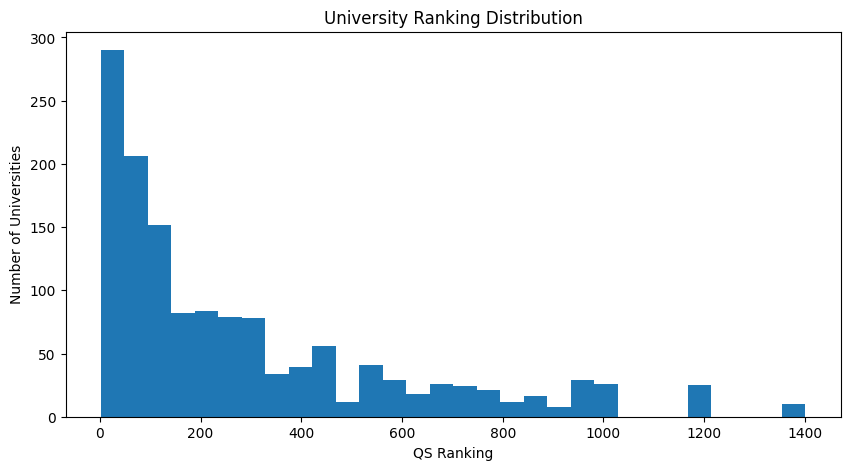

In [ ]:
import matplotlib.pyplot as plt

if "ranking_numeric" in features_df.columns:

    plt.figure(figsize=(10, 5))

    plt.hist(
        features_df["ranking_numeric"].dropna(),
        bins=30
    )

    plt.title("University Ranking Distribution")
    plt.xlabel("QS Ranking")
    plt.ylabel("Number of Universities")

    plt.show()

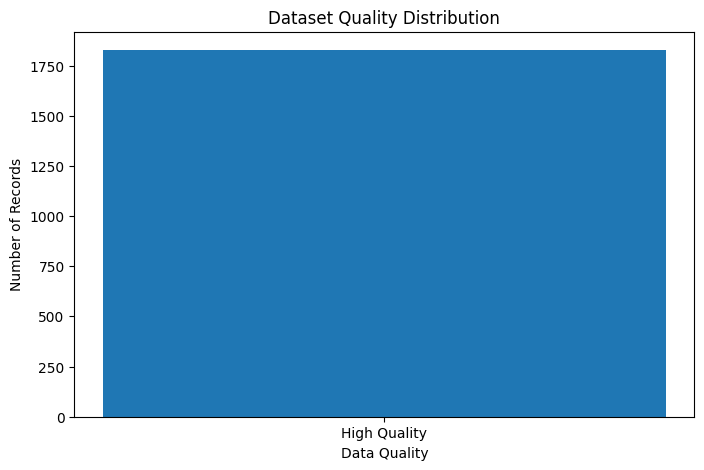

In [ ]:
quality_counts = (
    features_df["data_quality_label"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.title("Dataset Quality Distribution")
plt.xlabel("Data Quality")
plt.ylabel("Number of Records")

plt.show()

In [ ]:
recommendation_features = []

for col in [
    "university_key",
    "ranking_numeric",
    "ranking_score",
    "tuition_numeric",
    "living_cost_numeric",
    "total_estimated_cost",
    "affordability_score",
    "data_completeness_score",
    "data_quality_label",
    "match_score",
    "match_quality"
]:
    if col in features_df.columns:
        recommendation_features.append(col)

recommendation_df = features_df[
    recommendation_features
].copy()

print("Recommendation Dataset Shape:")
print(recommendation_df.shape)

display(recommendation_df.head())

Recommendation Dataset Shape:
(1827, 10)


,ranking_numeric,ranking_score,tuition_numeric,living_cost_numeric,total_estimated_cost,affordability_score,data_completeness_score,data_quality_label,match_score,match_quality
0,4.0,99.86,55400.0,83.5,55483.5,10.66,100.0,High Quality,100.0,Excellent
1,4.0,99.86,55400.0,83.5,55483.5,10.66,100.0,High Quality,100.0,Excellent
2,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality,100.0,Excellent
3,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality,100.0,Excellent
4,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality,100.0,Excellent


In [ ]:
feature_path = os.path.join(
    integration_path,
    "recommendation_ready_dataset.csv"
)

features_df.to_csv(
    feature_path,
    index=False
)

print("🎉 Recommendation-ready dataset saved!")
print(feature_path)

🎉 Recommendation-ready dataset saved!
/content/drive/MyDrive/StudyAbroad_AI/master_data/recommendation_ready_dataset.csv


In [ ]:
recommendation_path = os.path.join(
    integration_path,
    "recommendation_ready_dataset.csv"
)

features_df = pd.read_csv(recommendation_path)

print("Dataset Loaded Successfully!")
print("Shape:", features_df.shape)

display(features_df.head())

Dataset Loaded Successfully!
Shape: (1827, 56)


,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs,ranking_source,cost_source,match_quality,ranking_numeric,ranking_score,tuition_numeric,living_cost_numeric,total_estimated_cost,affordability_score,data_completeness_score,data_quality_label
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university,QS World University Rankings 2025,International Education Costs Dataset,Excellent,4.0,99.86,55400.0,83.5,55483.5,10.66,100.0,High Quality
1,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00,harvard university,harvard university,harvard university,100.0,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8,harvard university,QS World University Rankings 2025,International Education Costs Dataset,Excellent,4.0,99.86,55400.0,83.5,55483.5,10.66,100.0,High Quality
2,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality
3,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality
4,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,41200.0,75.8,41275.8,33.55,100.0,High Quality


In [ ]:
print("Available Columns:")

for col in features_df.columns:
    print(col)

Available Columns:
country
city
university
program
level
duration_years
tuition_usd
living_cost_index
rent_usd
visa_fee_usd
insurance_usd
exchange_rate
university_key_cost
cost_university_key
matched_qs_key
match_score
rank_2025
rank_2024
institution_name
location
region
size
focus
res
status
academic_reputation_score
academic_reputation_rank
employer_reputation_score
employer_reputation_rank
faculty_student_score
faculty_student_rank
citations_per_faculty_score
citations_per_faculty_rank
international_faculty_score
international_faculty_rank
international_students_score
international_students_rank
international_research_network_score
international_research_network_rank
employment_outcomes_score
employment_outcomes_rank
sustainability_score
sustainability_rank
overall_score
university_key_qs
ranking_source
cost_source
match_quality
ranking_numeric
ranking_score
tuition_numeric
living_cost_numeric
total_estimated_cost
affordability_score
data_completeness_score
data_quality_label


In [ ]:
recommendation_engine_df = features_df.copy()

In [ ]:
student_profile = {
    "cgpa": 7.5,
    "budget": 2500000,
    "preferred_country": "Germany",
    "preferred_field": "Computer Science",
    "ranking_priority": "High"
}

print("========== STUDENT PROFILE ==========")

for key, value in student_profile.items():
    print(f"{key}: {value}")

========== STUDENT PROFILE ==========
cgpa: 7.5
budget: 2500000
preferred_country: Germany
preferred_field: Computer Science
ranking_priority: High


In [ ]:
def calculate_budget_score(university_cost, student_budget):

    if pd.isna(university_cost):
        return 50

    if university_cost <= student_budget:
        return 100

    elif university_cost <= student_budget * 1.10:
        return 75

    elif university_cost <= student_budget * 1.25:
        return 50

    else:
        return 10

In [ ]:
if "total_estimated_cost" in recommendation_engine_df.columns:

    recommendation_engine_df["budget_score"] = (
        recommendation_engine_df["total_estimated_cost"]
        .apply(
            lambda x: calculate_budget_score(
                x,
                student_profile["budget"]
            )
        )
    )

    print("✅ Budget scores calculated")

✅ Budget scores calculated


In [ ]:
def calculate_ranking_weight(priority):

    weights = {
        "High": 0.40,
        "Medium": 0.25,
        "Low": 0.15
    }

    return weights.get(priority, 0.25)

In [ ]:
if "ranking_score" in recommendation_engine_df.columns:

    recommendation_engine_df[
        "student_ranking_score"
    ] = recommendation_engine_df[
        "ranking_score"
    ].fillna(50)

    print("✅ Ranking preference scores ready")

✅ Ranking preference scores ready


In [ ]:
country_columns = [
    col for col in recommendation_engine_df.columns
    if "country" in col.lower()
]

print("Possible Country Columns:", country_columns)

Possible Country Columns: ['country']


In [ ]:
country_col = country_columns[0] if country_columns else None

print("Selected Country Column:", country_col)

Selected Country Column: country


In [ ]:
def country_match_score(country, preferred_country):

    if pd.isna(country):
        return 50

    if str(country).strip().lower() == str(preferred_country).strip().lower():
        return 100

    return 40

In [ ]:
if country_col:

    recommendation_engine_df["country_score"] = (
        recommendation_engine_df[country_col]
        .apply(
            lambda x: country_match_score(
                x,
                student_profile["preferred_country"]
            )
        )
    )

    print("✅ Country preference scores calculated")

✅ Country preference scores calculated


In [ ]:
course_columns = [
    col for col in recommendation_engine_df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "course",
            "program",
            "field",
            "subject"
        ]
    )
]

print("Possible Course Columns:", course_columns)

Possible Course Columns: ['program']


In [ ]:
course_col = course_columns[0] if course_columns else None

print("Selected Course Column:", course_col)

Selected Course Column: program


In [ ]:
def course_match_score(course, preferred_field):

    if pd.isna(course):
        return 50

    course = str(course).lower()
    preferred_field = str(preferred_field).lower()

    if preferred_field in course:
        return 100

    return 30

In [ ]:
if course_col:

    recommendation_engine_df["course_score"] = (
        recommendation_engine_df[course_col]
        .apply(
            lambda x: course_match_score(
                x,
                student_profile["preferred_field"]
            )
        )
    )

    print("✅ Course matching completed")

✅ Course matching completed


In [ ]:
if "data_completeness_score" in recommendation_engine_df.columns:

    recommendation_engine_df["confidence_score"] = (
        recommendation_engine_df[
            "data_completeness_score"
        ].fillna(50)
    )

else:

    recommendation_engine_df["confidence_score"] = 50

In [ ]:
ranking_weight = calculate_ranking_weight(
    student_profile["ranking_priority"]
)

budget_weight = 0.30
country_weight = 0.15
course_weight = 0.10

confidence_weight = (
    1
    - ranking_weight
    - budget_weight
    - country_weight
    - course_weight
)

print("========== RECOMMENDATION WEIGHTS ==========")
print("Ranking:", ranking_weight)
print("Budget:", budget_weight)
print("Country:", country_weight)
print("Course:", course_weight)
print("Confidence:", confidence_weight)

========== RECOMMENDATION WEIGHTS ==========
Ranking: 0.4
Budget: 0.3
Country: 0.15
Course: 0.1
Confidence: 0.04999999999999999


In [ ]:
score_columns = [
    "student_ranking_score",
    "budget_score",
    "country_score",
    "course_score",
    "confidence_score"
]

for col in score_columns:
    if col not in recommendation_engine_df.columns:
        recommendation_engine_df[col] = 50

In [ ]:
recommendation_engine_df["recommendation_score"] = (

    recommendation_engine_df["student_ranking_score"]
    * ranking_weight

    +

    recommendation_engine_df["budget_score"]
    * budget_weight

    +

    recommendation_engine_df["country_score"]
    * country_weight

    +

    recommendation_engine_df["course_score"]
    * course_weight

    +

    recommendation_engine_df["confidence_score"]
    * confidence_weight
)

recommendation_engine_df[
    "recommendation_score"
] = recommendation_engine_df[
    "recommendation_score"
].round(2)

print("✅ Final recommendation scores calculated!")

✅ Final recommendation scores calculated!


In [ ]:
def recommendation_category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 65:
        return "Good Match"

    elif score >= 50:
        return "Moderate Match"

    else:
        return "Low Match"

In [ ]:
recommendation_engine_df[
    "recommendation_category"
] = recommendation_engine_df[
    "recommendation_score"
].apply(
    recommendation_category
)

In [ ]:
top_recommendations = (
    recommendation_engine_df
    .sort_values(
        by="recommendation_score",
        ascending=False
    )
    .head(10)
)

print("🎓 TOP 10 UNIVERSITY RECOMMENDATIONS")

display(top_recommendations)

🎓 TOP 10 UNIVERSITY RECOMMENDATIONS


,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs,ranking_source,cost_source,match_quality,ranking_numeric,ranking_score,tuition_numeric,living_cost_numeric,total_estimated_cost,affordability_score,data_completeness_score,data_quality_label,budget_score,student_ranking_score,country_score,course_score,confidence_score,recommendation_score,recommendation_category
14,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92,technical university of munich,technical university of munich,technical university of munich,100.0,28,37,Technical University of Munich,Germany,Europe,XL,FO,VH,A,83.0,61,98.6,17,76.8,155,75.9,133,80.4,236,98.6,64,95.6,68,34.5,365,93.1,70,83.2,technical university of munich,QS World University Rankings 2025,International Education Costs Dataset,Excellent,28.0,98.14,500.0,70.5,570.5,99.14,100.0,High Quality,100,98.14,100,30,100.0,92.26,Excellent Match
500,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match
501,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match
499,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match
495,UK,Oxford,University of Oxford,Computer Science,Bachelor,3.0,37900,77.8,1850,490,800,0.79,university of oxford,university of oxford,university of oxford,100.0,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,2,100.0,5,100.0,8,84.8,93,98.1,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9,university of oxford,QS World University Rankings 2025,International Education Costs Dataset,Excellent,3.0,99.93,37900.0,77.8,37977.8,38.87,100.0,High Quality,100,99.93,40,100,100.0,90.97,Excellent Match
498,UK,Oxford,University of Oxford,Computer Science,Bachelor,3.0,37900,77.8,1850,490,800,0.79,university of oxford,university of oxford,university of oxford,100.0,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,2,100.0,5,100.0,8,84.8,93,98.1,120,97.7,73,10

In [ ]:
def generate_recommendation_reason(row):

    reasons = []

    if row["budget_score"] >= 90:
        reasons.append("Fits your budget")

    if row["country_score"] >= 90:
        reasons.append("Matches preferred country")

    if row["course_score"] >= 90:
        reasons.append("Matches your preferred field")

    if row["student_ranking_score"] >= 80:
        reasons.append("Strong global ranking")

    if row["confidence_score"] >= 75:
        reasons.append("High data confidence")

    return ", ".join(reasons)

In [ ]:
recommendation_engine_df[
    "recommendation_reason"
] = recommendation_engine_df.apply(
    generate_recommendation_reason,
    axis=1
)

In [ ]:
display(
    recommendation_engine_df[
        [
            "recommendation_score",
            "recommendation_category",
            "recommendation_reason"
        ]
    ]
    .sort_values(
        by="recommendation_score",
        ascending=False
    )
    .head(10)
)

,recommendation_score,recommendation_category,recommendation_reason
14,92.26,Excellent Match,"Fits your budget, Matches preferred country, S..."
500,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
501,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
499,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
495,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."
498,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."
496,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."
497,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."
1034,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."
1037,90.97,Excellent Match,"Fits your budget, Matches your preferred field..."


In [ ]:
def recommend_universities(
    data,
    student_profile,
    top_n=10
):

    df = data.copy()

    # Budget Score
    if "total_estimated_cost" in df.columns:
        df["budget_score"] = df[
            "total_estimated_cost"
        ].apply(
            lambda x: calculate_budget_score(
                x,
                student_profile["budget"]
            )
        )
    else:
        df["budget_score"] = 50

    # Ranking Score
    df["student_ranking_score"] = (
        df["ranking_score"].fillna(50)
        if "ranking_score" in df.columns
        else 50
    )

    # Country Score
    if country_col and country_col in df.columns:
        df["country_score"] = df[country_col].apply(
            lambda x: country_match_score(
                x,
                student_profile["preferred_country"]
            )
        )
    else:
        df["country_score"] = 50

    # Course Score
    if course_col and course_col in df.columns:
        df["course_score"] = df[course_col].apply(
            lambda x: course_match_score(
                x,
                student_profile["preferred_field"]
            )
        )
    else:
        df["course_score"] = 50

    # Confidence
    df["confidence_score"] = (
        df["data_completeness_score"].fillna(50)
        if "data_completeness_score" in df.columns
        else 50
    )

    # Dynamic weights
    ranking_weight = calculate_ranking_weight(
        student_profile["ranking_priority"]
    )

    budget_weight = 0.30
    country_weight = 0.15
    course_weight = 0.10

    confidence_weight = (
        1
        - ranking_weight
        - budget_weight
        - country_weight
        - course_weight
    )

    # Final Score
    df["recommendation_score"] = (
        df["student_ranking_score"] * ranking_weight
        + df["budget_score"] * budget_weight
        + df["country_score"] * country_weight
        + df["course_score"] * course_weight
        + df["confidence_score"] * confidence_weight
    ).round(2)

    df["recommendation_category"] = (
        df["recommendation_score"]
        .apply(recommendation_category)
    )

    df["recommendation_reason"] = df.apply(
        generate_recommendation_reason,
        axis=1
    )

    return (
        df
        .sort_values(
            "recommendation_score",
            ascending=False
        )
        .head(top_n)
    )

In [ ]:
student_1 = {
    "cgpa": 8.5,
    "budget": 3000000,
    "preferred_country": "Germany",
    "preferred_field": "Computer Science",
    "ranking_priority": "High"
}

result_1 = recommend_universities(
    features_df,
    student_1
)

display(result_1)

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs,ranking_source,cost_source,match_quality,ranking_numeric,ranking_score,tuition_numeric,living_cost_numeric,total_estimated_cost,affordability_score,data_completeness_score,data_quality_label,budget_score,student_ranking_score,country_score,course_score,confidence_score,recommendation_score,recommendation_category,recommendation_reason
14,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92,technical university of munich,technical university of munich,technical university of munich,100.0,28,37,Technical University of Munich,Germany,Europe,XL,FO,VH,A,83.0,61,98.6,17,76.8,155,75.9,133,80.4,236,98.6,64,95.6,68,34.5,365,93.1,70,83.2,technical university of munich,QS World University Rankings 2025,International Education Costs Dataset,Excellent,28.0,98.14,500.0,70.5,570.5,99.14,100.0,High Quality,100,98.14,100,30,100.0,92.26,Excellent Match,"Fits your budget, Matches preferred country, S..."
500,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
501,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
499,UK,London,Imperial College London,Computer Science,Bachelor,3.0,37500,83.2,2200,490,800,0.79,imperial college london,imperial college london,imperial college london,100.0,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5,imperial college london,QS World University Rankings 2025,International Education Costs Dataset,Excellent,2.0,100.00,37500.0,83.2,37583.2,39.50,100.0,High Quality,100,100.00,40,100,100.0,91.00,Excellent Match,"Fits your budget, Matches your preferred field..."
495,UK,Oxford,University of Oxford,Computer Science,Bachelor,3.0,37900,77.8,1850,490,800,0.79,university of oxford,university of oxford,university of oxford,100.0,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,2,100.0,5,100.0,8,84.8,93,98.1,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9,university of oxford,QS World University Rankings 2025,International Education Costs Dataset,Excellent,3.0,99.93,37900.0,77.8,37977.8,38.87,100.0,High Quality,100,99.93,40,100,100.0,90.97,Excellent Match,"Fits your budget, Matches your preferred

In [ ]:
student_2 = {
    "cgpa": 7.0,
    "budget": 1500000,
    "preferred_country": "Canada",
    "preferred_field": "Data Science",
    "ranking_priority": "Medium"
}

result_2 = recommend_universities(
    features_df,
    student_2
)

display(result_2)

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate,university_key_cost,cost_university_key,matched_qs_key,match_score,rank_2025,rank_2024,institution_name,location,region,size,focus,res,status,academic_reputation_score,academic_reputation_rank,employer_reputation_score,employer_reputation_rank,faculty_student_score,faculty_student_rank,citations_per_faculty_score,citations_per_faculty_rank,international_faculty_score,international_faculty_rank,international_students_score,international_students_rank,international_research_network_score,international_research_network_rank,employment_outcomes_score,employment_outcomes_rank,sustainability_score,sustainability_rank,overall_score,university_key_qs,ranking_source,cost_source,match_quality,ranking_numeric,ranking_score,tuition_numeric,living_cost_numeric,total_estimated_cost,affordability_score,data_completeness_score,data_quality_label,budget_score,student_ranking_score,country_score,course_score,confidence_score,recommendation_score,recommendation_category,recommendation_reason
1081,Canada,Edmonton,University of Alberta,Data Science,Master,2.0,37000,64.3,1100,235,750,1.35,university of alberta,university of alberta,university of alberta,100.0,96,111,University of Alberta,Canada,Americas,XL,FC,VH,A,57.0,136,42.2,222,39.1,400,61.3,194,98.3,116,71.0,207,96.0,55,70.0,159,97.6,28,61.2,university of alberta,QS World University Rankings 2025,International Education Costs Dataset,Excellent,96.0,93.28,37000.0,64.3,37064.3,40.34,100.0,High Quality,100,93.28,100,100,100.0,98.32,Excellent Match,"Fits your budget, Matches preferred country, M..."
1078,Canada,Edmonton,University of Alberta,Data Science,Master,2.0,37000,64.3,1100,235,750,1.35,university of alberta,university of alberta,university of alberta,100.0,96,111,University of Alberta,Canada,Americas,XL,FC,VH,A,57.0,136,42.2,222,39.1,400,61.3,194,98.3,116,71.0,207,96.0,55,70.0,159,97.6,28,61.2,university of alberta,QS World University Rankings 2025,International Education Costs Dataset,Excellent,96.0,93.28,37000.0,64.3,37064.3,40.34,100.0,High Quality,100,93.28,100,100,100.0,98.32,Excellent Match,"Fits your budget, Matches preferred country, M..."
1079,Canada,Edmonton,University of Alberta,Data Science,Master,2.0,37000,64.3,1100,235,750,1.35,university of alberta,university of alberta,university of alberta,100.0,96,111,University of Alberta,Canada,Americas,XL,FC,VH,A,57.0,136,42.2,222,39.1,400,61.3,194,98.3,116,71.0,207,96.0,55,70.0,159,97.6,28,61.2,university of alberta,QS World University Rankings 2025,International Education Costs Dataset,Excellent,96.0,93.28,37000.0,64.3,37064.3,40.34,100.0,High Quality,100,93.28,100,100,100.0,98.32,Excellent Match,"Fits your budget, Matches preferred country, M..."
1080,Canada,Edmonton,University of Alberta,Data Science,Master,2.0,37000,64.3,1100,235,750,1.35,university of alberta,university of alberta,university of alberta,100.0,96,111,University of Alberta,Canada,Americas,XL,FC,VH,A,57.0,136,42.2,222,39.1,400,61.3,194,98.3,116,71.0,207,96.0,55,70.0,159,97.6,28,61.2,university of alberta,QS World University Rankings 2025,International Education Costs Dataset,Excellent,96.0,93.28,37000.0,64.3,37064.3,40.34,100.0,High Quality,100,93.28,100,100,100.0,98.32,Excellent Match,"Fits your budget, Matches preferred country, M..."
278,Canada,Halifax,Dalhousie University,Data Science,Master,2.0,28500,64.5,1200,235,900,1.35,dalhousie university,dalhousie university,dalhousie university,100.0,275,298,Dalhousie University,Canada,Americas,L,FC,VH,A,19.4,463,16.7,513,12.9,701+,53.5,239,99.9,86,74.6,189,77.4,369,30.1,416,87.9,109,38.2,dalhousie university,QS World University Rankings 2025,International Education Costs Dataset,Excellent,275.0,80.49,28500.0,64.5,28564.5,54.03,100.0,High Quality,100,80.49,100,100,100.0,95.12,Excellent Match,"Fits your budget, Matches preferred country, M..."
277,Canada,Halifax,Dalhousie University,Data Sci

In [ ]:
output_path = os.path.join(
    project_path,
    "outputs",
    "sample_university_recommendations.csv"
)

result_1.to_csv(
    output_path,
    index=False
)

print("✅ Sample recommendations saved!")

✅ Sample recommendations saved!


In [ ]:
import pandas as pd
import numpy as np
import os

feature_path = os.path.join(
    integration_path,
    "recommendation_ready_dataset.csv"
)

country_df = pd.read_csv(feature_path)

print("✅ Dataset Loaded")
print("Shape:", country_df.shape)

✅ Dataset Loaded
Shape: (1827, 56)


In [ ]:
country_candidates = [
    col for col in country_df.columns
    if "country" in col.lower()
]

print("Possible Country Columns:")
print(country_candidates)

Possible Country Columns:
['country']


In [ ]:
country_col = country_candidates[0] if country_candidates else None

print("Selected Country Column:", country_col)

Selected Country Column: country


In [ ]:
if country_col:

    country_distribution = (
        country_df[country_col]
        .value_counts()
        .reset_index()
    )

    country_distribution.columns = [
        "Country",
        "University_Count"
    ]

    print("🌍 COUNTRY DISTRIBUTION")

    display(country_distribution.head(20))

🌍 COUNTRY DISTRIBUTION


,Country,University_Count
0,Australia,356
1,Canada,244
2,USA,216
3,UK,215
4,Germany,61
5,France,53
6,Denmark,45
7,Italy,37
8,Netherlands,37
9,Singapore,34


In [ ]:
aggregation_dict = {}

if "total_estimated_cost" in country_df.columns:
    aggregation_dict["total_estimated_cost"] = "mean"

if "ranking_numeric" in country_df.columns:
    aggregation_dict["ranking_numeric"] = "mean"

if "ranking_score" in country_df.columns:
    aggregation_dict["ranking_score"] = "mean"

if "affordability_score" in country_df.columns:
    aggregation_dict["affordability_score"] = "mean"

if "data_completeness_score" in country_df.columns:
    aggregation_dict["data_completeness_score"] = "mean"


country_summary = (
    country_df
    .groupby(country_col)
    .agg(aggregation_dict)
    .reset_index()
)

country_summary["university_count"] = (
    country_df
    .groupby(country_col)
    .size()
    .values
)

print("✅ Country-level summary created")

display(country_summary.head())

✅ Country-level summary created


,country,total_estimated_cost,ranking_numeric,ranking_score,affordability_score,data_completeness_score,university_count
0,Algeria,1135.680000,806.666667,42.483333,98.230000,90.000000,5
1,Argentina,40.350000,NaN,NaN,99.995000,75.000000,8
2,Australia,34767.379775,160.451713,88.674268,44.040112,97.542135,356
3,Austria,1571.066667,382.250000,72.820000,97.528889,86.111111,9
4,Bahrain,7662.860000,745.000000,46.895000,87.716000,85.000000,5


In [ ]:
rename_mapping = {
    country_col: "country",
    "total_estimated_cost": "avg_estimated_cost",
    "ranking_numeric": "avg_ranking",
    "ranking_score": "avg_ranking_score",
    "affordability_score": "avg_affordability_score",
    "data_completeness_score": "avg_data_quality"
}

country_summary = country_summary.rename(
    columns=rename_mapping
)

display(country_summary.head())

,country,avg_estimated_cost,avg_ranking,avg_ranking_score,avg_affordability_score,avg_data_quality,university_count
0,Algeria,1135.680000,806.666667,42.483333,98.230000,90.000000,5
1,Argentina,40.350000,NaN,NaN,99.995000,75.000000,8
2,Australia,34767.379775,160.451713,88.674268,44.040112,97.542135,356
3,Austria,1571.066667,382.250000,72.820000,97.528889,86.111111,9
4,Bahrain,7662.860000,745.000000,46.895000,87.716000,85.000000,5


In [ ]:
def calculate_country_budget_score(
    avg_cost,
    student_budget
):

    if pd.isna(avg_cost):
        return 50

    if avg_cost <= student_budget:
        return 100

    elif avg_cost <= student_budget * 1.10:
        return 75

    elif avg_cost <= student_budget * 1.25:
        return 50

    else:
        return 10

In [ ]:
country_student_profile = {
    "budget": 2500000,
    "preferred_country": "Germany",
    "ranking_priority": "High"
}

print(country_student_profile)

{'budget': 2500000, 'preferred_country': 'Germany', 'ranking_priority': 'High'}


In [ ]:
if "avg_estimated_cost" in country_summary.columns:

    country_summary["budget_compatibility_score"] = (
        country_summary["avg_estimated_cost"]
        .apply(
            lambda x:
            calculate_country_budget_score(
                x,
                country_student_profile["budget"]
            )
        )
    )

    print("✅ Budget compatibility calculated")

✅ Budget compatibility calculated


In [ ]:
def calculate_country_preference(
    country,
    preferred_country
):

    if pd.isna(country):
        return 50

    if (
        str(country).strip().lower()
        ==
        str(preferred_country).strip().lower()
    ):
        return 100

    return 50

In [ ]:
country_summary["country_preference_score"] = (
    country_summary["country"]
    .apply(
        lambda x:
        calculate_country_preference(
            x,
            country_student_profile["preferred_country"]
        )
    )
)

In [ ]:
if "avg_ranking_score" in country_summary.columns:

    country_summary["country_ranking_score"] = (
        country_summary["avg_ranking_score"]
        .fillna(50)
    )

else:

    country_summary["country_ranking_score"] = 50

In [ ]:
max_universities = country_summary[
    "university_count"
].max()

country_summary["university_availability_score"] = (
    country_summary["university_count"]
    / max_universities
    * 100
).round(2)

In [ ]:
if "avg_data_quality" in country_summary.columns:

    country_summary["country_confidence_score"] = (
        country_summary["avg_data_quality"]
        .fillna(50)
    )

else:

    country_summary["country_confidence_score"] = 50

In [ ]:
country_summary["country_recommendation_score"] = (

    country_summary["budget_compatibility_score"] * 0.35

    +

    country_summary["country_ranking_score"] * 0.25

    +

    country_summary["country_preference_score"] * 0.20

    +

    country_summary[
        "university_availability_score"
    ] * 0.10

    +

    country_summary[
        "country_confidence_score"
    ] * 0.10

).round(2)

In [ ]:
def country_category(score):

    if score >= 80:
        return "Highly Recommended"

    elif score >= 65:
        return "Recommended"

    elif score >= 50:
        return "Consider"

    else:
        return "Low Compatibility"

In [ ]:
country_summary["recommendation_category"] = (
    country_summary[
        "country_recommendation_score"
    ].apply(country_category)
)

In [ ]:
top_countries = (
    country_summary
    .sort_values(
        by="country_recommendation_score",
        ascending=False
    )
    .head(10)
)

print("🌍 TOP COUNTRY RECOMMENDATIONS")

display(top_countries)

🌍 TOP COUNTRY RECOMMENDATIONS


,country,avg_estimated_cost,avg_ranking,avg_ranking_score,avg_affordability_score,avg_data_quality,university_count,budget_compatibility_score,country_preference_score,country_ranking_score,university_availability_score,country_confidence_score,country_recommendation_score,recommendation_category
2,Australia,34767.379775,160.451713,88.674268,44.040112,97.542135,356,100,50,88.674268,100.00,97.542135,86.92,Highly Recommended
65,UK,32372.223256,124.378641,91.251602,47.898698,98.953488,215,100,50,91.251602,60.39,98.953488,83.75,Highly Recommended
22,Germany,250.534426,402.714286,71.356667,99.655246,83.606557,61,100,100,71.356667,17.13,83.606557,82.91,Highly Recommended
66,USA,48933.638889,140.157895,90.123759,21.214259,90.393519,216,100,50,90.123759,60.67,90.393519,82.64,Highly Recommended
9,Canada,30216.956148,321.294643,77.177545,51.371598,97.950820,244,100,50,77.177545,68.54,97.950820,80.94,Highly Recommended
60,Taiwan,5262.800000,68.000000,95.280000,91.580000,100.000000,1,100,50,95.280000,0.28,100.000000,78.85,Recommended
10,China,7819.221429,117.384615,91.752308,87.460000,98.214286,14,100,50,91.752308,3.93,98.214286,78.15,Recommended
15,Denmark,1989.324444,197.159091,86.047500,96.854667,99.444444,45,100,50,86.047500,12.64,99.444444,77.72,Recommended
55,South Africa,5949.200000,171.000000,87.920000,90.470000,100.000000,1,100,50,87.920000,0.28,100.000000,77.01,Recommended
41,Netherlands,13692.975676,177.000000,87.491500,77.997027,88.513514,37,100,50,87.491500,10.39,88.513514,76.76,Recommended


In [ ]:
def generate_country_reason(row):

    reasons = []

    if row["budget_compatibility_score"] >= 90:
        reasons.append("Fits your budget")

    if row["country_ranking_score"] >= 75:
        reasons.append("Strong university rankings")

    if row["country_preference_score"] >= 90:
        reasons.append("Matches your country preference")

    if row["university_availability_score"] >= 70:
        reasons.append("Many university options")

    return ", ".join(reasons)

In [ ]:
country_summary["recommendation_reason"] = (
    country_summary.apply(
        generate_country_reason,
        axis=1
    )
)

In [ ]:
top_countries = (
    country_summary
    .sort_values(
        by="country_recommendation_score",
        ascending=False
    )
    .head(10)
)

display(
    top_countries[
        [
            "country",
            "university_count",
            "country_recommendation_score",
            "recommendation_category",
            "recommendation_reason"
        ]
    ]
)

,country,university_count,country_recommendation_score,recommendation_category,recommendation_reason
2,Australia,356,86.92,Highly Recommended,"Fits your budget, Strong university rankings, ..."
65,UK,215,83.75,Highly Recommended,"Fits your budget, Strong university rankings"
22,Germany,61,82.91,Highly Recommended,"Fits your budget, Matches your country preference"
66,USA,216,82.64,Highly Recommended,"Fits your budget, Strong university rankings"
9,Canada,244,80.94,Highly Recommended,"Fits your budget, Strong university rankings"
60,Taiwan,1,78.85,Recommended,"Fits your budget, Strong university rankings"
10,China,14,78.15,Recommended,"Fits your budget, Strong university rankings"
15,Denmark,45,77.72,Recommended,"Fits your budget, Strong university rankings"
55,South Africa,1,77.01,Recommended,"Fits your budget, Strong university rankings"
41,Netherlands,37,76.76,Recommended,"Fits your budget, Strong university rankings"


In [ ]:
def recommend_countries(
    country_data,
    budget,
    preferred_country=None,
    top_n=10
):

    df = country_data.copy()

    # Budget score
    if "avg_estimated_cost" in df.columns:

        df["budget_compatibility_score"] = (
            df["avg_estimated_cost"].apply(
                lambda x:
                calculate_country_budget_score(
                    x,
                    budget
                )
            )
        )

    else:
        df["budget_compatibility_score"] = 50


    # Country preference
    df["country_preference_score"] = (
        df["country"].apply(
            lambda x:
            calculate_country_preference(
                x,
                preferred_country
            )
        )
    )


    # Ranking
    df["country_ranking_score"] = (
        df["avg_ranking_score"].fillna(50)
        if "avg_ranking_score" in df.columns
        else 50
    )


    # Final score
    df["country_recommendation_score"] = (

        df["budget_compatibility_score"] * 0.35
        + df["country_ranking_score"] * 0.25
        + df["country_preference_score"] * 0.20
        + df["university_availability_score"] * 0.10
        + df["country_confidence_score"] * 0.10

    ).round(2)


    df["recommendation_category"] = (
        df[
            "country_recommendation_score"
        ].apply(country_category)
    )


    df["recommendation_reason"] = (
        df.apply(
            generate_country_reason,
            axis=1
        )
    )


    return (
        df
        .sort_values(
            by="country_recommendation_score",
            ascending=False
        )
        .head(top_n)
    )

In [ ]:
result_countries = recommend_countries(
    country_summary,
    budget=2500000,
    preferred_country="Germany",
    top_n=10
)

display(result_countries)

,country,avg_estimated_cost,avg_ranking,avg_ranking_score,avg_affordability_score,avg_data_quality,university_count,budget_compatibility_score,country_preference_score,country_ranking_score,university_availability_score,country_confidence_score,country_recommendation_score,recommendation_category,recommendation_reason
2,Australia,34767.379775,160.451713,88.674268,44.040112,97.542135,356,100,50,88.674268,100.00,97.542135,86.92,Highly Recommended,"Fits your budget, Strong university rankings, ..."
65,UK,32372.223256,124.378641,91.251602,47.898698,98.953488,215,100,50,91.251602,60.39,98.953488,83.75,Highly Recommended,"Fits your budget, Strong university rankings"
22,Germany,250.534426,402.714286,71.356667,99.655246,83.606557,61,100,100,71.356667,17.13,83.606557,82.91,Highly Recommended,"Fits your budget, Matches your country preference"
66,USA,48933.638889,140.157895,90.123759,21.214259,90.393519,216,100,50,90.123759,60.67,90.393519,82.64,Highly Recommended,"Fits your budget, Strong university rankings"
9,Canada,30216.956148,321.294643,77.177545,51.371598,97.950820,244,100,50,77.177545,68.54,97.950820,80.94,Highly Recommended,"Fits your budget, Strong university rankings"
60,Taiwan,5262.800000,68.000000,95.280000,91.580000,100.000000,1,100,50,95.280000,0.28,100.000000,78.85,Recommended,"Fits your budget, Strong university rankings"
10,China,7819.221429,117.384615,91.752308,87.460000,98.214286,14,100,50,91.752308,3.93,98.214286,78.15,Recommended,"Fits your budget, Strong university rankings"
15,Denmark,1989.324444,197.159091,86.047500,96.854667,99.444444,45,100,50,86.047500,12.64,99.444444,77.72,Recommended,"Fits your budget, Strong university rankings"
55,South Africa,5949.200000,171.000000,87.920000,90.470000,100.000000,1,100,50,87.920000,0.28,100.000000,77.01,Recommended,"Fits your budget, Strong university rankings"
41,Netherlands,13692.975676,177.000000,87.491500,77.997027,88.513514,37,100,50,87.491500,10.39,88.513514,76.76,Recommended,"Fits your budget, Strong university rankings"


In [ ]:
result_countries_2 = recommend_countries(
    country_summary,
    budget=1500000,
    preferred_country="Canada",
    top_n=10
)

display(result_countries_2)

,country,avg_estimated_cost,avg_ranking,avg_ranking_score,avg_affordability_score,avg_data_quality,university_count,budget_compatibility_score,country_preference_score,country_ranking_score,university_availability_score,country_confidence_score,country_recommendation_score,recommendation_category,recommendation_reason
9,Canada,30216.956148,321.294643,77.177545,51.371598,97.950820,244,100,100,77.177545,68.54,97.950820,90.94,Highly Recommended,"Fits your budget, Strong university rankings, ..."
2,Australia,34767.379775,160.451713,88.674268,44.040112,97.542135,356,100,50,88.674268,100.00,97.542135,86.92,Highly Recommended,"Fits your budget, Strong university rankings, ..."
65,UK,32372.223256,124.378641,91.251602,47.898698,98.953488,215,100,50,91.251602,60.39,98.953488,83.75,Highly Recommended,"Fits your budget, Strong university rankings"
66,USA,48933.638889,140.157895,90.123759,21.214259,90.393519,216,100,50,90.123759,60.67,90.393519,82.64,Highly Recommended,"Fits your budget, Strong university rankings"
60,Taiwan,5262.800000,68.000000,95.280000,91.580000,100.000000,1,100,50,95.280000,0.28,100.000000,78.85,Recommended,"Fits your budget, Strong university rankings"
10,China,7819.221429,117.384615,91.752308,87.460000,98.214286,14,100,50,91.752308,3.93,98.214286,78.15,Recommended,"Fits your budget, Strong university rankings"
15,Denmark,1989.324444,197.159091,86.047500,96.854667,99.444444,45,100,50,86.047500,12.64,99.444444,77.72,Recommended,"Fits your budget, Strong university rankings"
55,South Africa,5949.200000,171.000000,87.920000,90.470000,100.000000,1,100,50,87.920000,0.28,100.000000,77.01,Recommended,"Fits your budget, Strong university rankings"
41,Netherlands,13692.975676,177.000000,87.491500,77.997027,88.513514,37,100,50,87.491500,10.39,88.513514,76.76,Recommended,"Fits your budget, Strong university rankings"
32,Israel,12076.200000,209.000000,85.200000,80.600000,100.000000,1,100,50,85.200000,0.28,100.000000,76.33,Recommended,"Fits your budget, Strong university rankings"


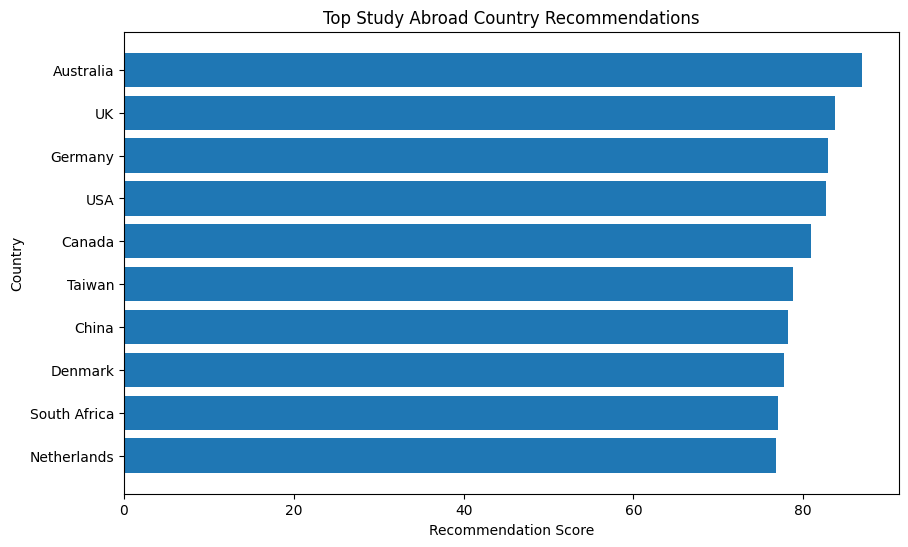

In [ ]:
import matplotlib.pyplot as plt

plot_data = (
    result_countries
    .sort_values(
        "country_recommendation_score"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["country"],
    plot_data[
        "country_recommendation_score"
    ]
)

plt.xlabel("Recommendation Score")
plt.ylabel("Country")

plt.title(
    "Top Study Abroad Country Recommendations"
)

plt.show()

In [ ]:
country_output_path = os.path.join(
    integration_path,
    "country_intelligence_dataset.csv"
)

country_summary.to_csv(
    country_output_path,
    index=False
)

print("🎉 Country Intelligence Dataset Saved!")
print(country_output_path)

🎉 Country Intelligence Dataset Saved!
/content/drive/MyDrive/StudyAbroad_AI/master_data/country_intelligence_dataset.csv


In [ ]:
scholarship_path = os.path.join(
    clean_data_path,
    "scholarships_clean.csv"
)

scholarship_engine_df = pd.read_csv(
    scholarship_path
)

print("✅ Scholarship dataset loaded!")
print("Shape:", scholarship_engine_df.shape)

display(scholarship_engine_df.head())

✅ Scholarship dataset loaded!
Shape: (10410, 7)


,scholarship_name,deadline,amount,description,location,years,link
0,Order Sons of Italy in America National Leader...,Unknown deadline,500.0,Applicant must be of Italian heritage and be a...,No Geographic Restrictions,"['College junior', 'College freshman', 'Colleg...",https://www.collegescholarships.org/financial-...
1,Entrance Scholarship,Unknown deadline,500.0,Applicant must be an incoming first-year stude...,No Geographic Restrictions,['College freshman'],https://www.collegescholarships.org/financial-...
2,Agnes Jones Jackson Scholarship,Unknown deadline,500.0,Applicant must be current member of the NAACP ...,No Geographic Restrictions,"['College freshman', 'Master&#039;s-level stud...",https://www.collegescholarships.org/financial-...
3,Fellowship in Jewish Studies,Unknown deadline,500.0,Applicant must have an interest in Jewish stud...,No Geographic Restrictions,['High school senior'],https://www.collegescholarships.org/financial-...
4,Doctoral Scholarship,Unknown deadline,500.0,Applicant must be a doctoral student specializ...,No Geographic Restrictions,['Doctoral-level study'],https://www.collegescholarships.org/financial-...


In [ ]:
print("========== SCHOLARSHIP DATASET COLUMNS ==========\n")

for i, col in enumerate(scholarship_engine_df.columns, 1):
    print(f"{i}. {col}")

========== SCHOLARSHIP DATASET COLUMNS ==========

1. scholarship_name
2. deadline
3. amount
4. description
5. location
6. years
7. link


In [ ]:
display(scholarship_engine_df.sample(
    min(5, len(scholarship_engine_df)),
    random_state=42
))

,scholarship_name,deadline,amount,description,location,years,link
3952,License Plate Scholarship,Unknown deadline,600.0,"Applicant must rank in the top fifth of class,...",No Geographic Restrictions,['College freshman'],https://www.collegescholarships.org/financial-...
4597,Miami Herald Minority Scholarship,Unknown deadline,500.0,Applicant must be a minority student planning ...,No Geographic Restrictions,"['College freshman', 'College sophomore', 'Col...",https://www.collegescholarships.org/financial-...
9624,Robert E. Drew Memorial Scholarship,Unknown deadline,500.0,Selection is based upon financial need.,No Geographic Restrictions,"['College freshman', 'College junior', 'Colleg...",https://www.collegescholarships.org/financial-...
6871,William B. Howell Memorial Scholarship,Unknown deadline,500.0,Applicant must be a full-time student who is m...,"Michigan, Florida, Ohio","['College senior', 'College sophomore', 'Colle...",https://www.collegescholarships.org/financial-...
4294,Sophus C. Goth Memorial Scholarship,Unknown deadline,850.0,Applicant must be a member in good standing of...,No Geographic Restrictions,['No Restrictions'],https://www.collegescholarships.org/financial-...


In [ ]:
def detect_scholarship_column(df, keywords):

    for keyword in keywords:
        for col in df.columns:
            if keyword.lower() in col.lower():
                return col

    return None


scholarship_columns = {

    "name": detect_scholarship_column(
        scholarship_engine_df,
        ["scholarship_name", "name", "title"]
    ),

    "country": detect_scholarship_column(
        scholarship_engine_df,
        ["country", "location"]
    ),

    "field": detect_scholarship_column(
        scholarship_engine_df,
        ["field", "subject", "discipline", "course"]
    ),

    "degree": detect_scholarship_column(
        scholarship_engine_df,
        ["degree", "level"]
    ),

    "amount": detect_scholarship_column(
        scholarship_engine_df,
        ["amount", "award", "value", "funding"]
    ),

    "eligibility": detect_scholarship_column(
        scholarship_engine_df,
        ["eligibility", "criteria", "requirement"]
    ),

    "deadline": detect_scholarship_column(
        scholarship_engine_df,
        ["deadline", "date"]
    )
}

print("========== DETECTED COLUMNS ==========")

for key, value in scholarship_columns.items():
    print(f"{key}: {value}")

========== DETECTED COLUMNS ==========
name: scholarship_name
country: location
field: None
degree: None
amount: amount
eligibility: None
deadline: deadline


In [ ]:
scholarship_student = {
    "cgpa": 8.0,
    "preferred_country": "Germany",
    "preferred_field": "Computer Science",
    "degree_level": "Masters"
}

print("========== STUDENT SCHOLARSHIP PROFILE ==========")

for key, value in scholarship_student.items():
    print(f"{key}: {value}")

========== STUDENT SCHOLARSHIP PROFILE ==========
cgpa: 8.0
preferred_country: Germany
preferred_field: Computer Science
degree_level: Masters


In [ ]:
def scholarship_country_score(
    scholarship_country,
    preferred_country
):

    if pd.isna(scholarship_country):
        return 50

    scholarship_country = str(
        scholarship_country
    ).lower()

    preferred_country = str(
        preferred_country
    ).lower()

    if preferred_country in scholarship_country:
        return 100

    return 40

In [ ]:
country_col = scholarship_columns["country"]

if country_col:

    scholarship_engine_df["country_match_score"] = (
        scholarship_engine_df[country_col]
        .apply(
            lambda x:
            scholarship_country_score(
                x,
                scholarship_student["preferred_country"]
            )
        )
    )

else:

    scholarship_engine_df[
        "country_match_score"
    ] = 50

In [ ]:
def degree_match_score(
    scholarship_degree,
    student_degree
):

    if pd.isna(scholarship_degree):
        return 50

    scholarship_degree = str(
        scholarship_degree
    ).lower()

    student_degree = str(
        student_degree
    ).lower()

    if student_degree in scholarship_degree:
        return 100

    return 30

In [ ]:
degree_col = scholarship_columns["degree"]

if degree_col:

    scholarship_engine_df["degree_match_score"] = (
        scholarship_engine_df[degree_col]
        .apply(
            lambda x:
            degree_match_score(
                x,
                scholarship_student["degree_level"]
            )
        )
    )

else:

    scholarship_engine_df[
        "degree_match_score"
    ] = 50

In [ ]:
text_columns = []

for key in ["field", "eligibility", "name"]:

    col = scholarship_columns.get(key)

    if col and col in scholarship_engine_df.columns:
        text_columns.append(col)

print("Text columns used:", text_columns)

Text columns used: ['scholarship_name']


In [ ]:
scholarship_engine_df["combined_scholarship_text"] = (
    scholarship_engine_df[text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

display(
    scholarship_engine_df[
        ["combined_scholarship_text"]
    ].head()
)

,combined_scholarship_text
0,Order Sons of Italy in America National Leader...
1,Entrance Scholarship
2,Agnes Jones Jackson Scholarship
3,Fellowship in Jewish Studies
4,Doctoral Scholarship


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ Scikit-learn ready")

✅ Scikit-learn ready


In [ ]:
all_text = scholarship_engine_df[
    "combined_scholarship_text"
].tolist()

student_query = scholarship_student[
    "preferred_field"
]

corpus = [student_query] + all_text

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    corpus
)

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
).flatten()

scholarship_engine_df[
    "field_similarity_score"
] = (
    similarity_scores * 100
).round(2)

print("✅ Field similarity calculated")

✅ Field similarity calculated


In [ ]:
display(
    scholarship_engine_df[
        [
            scholarship_columns["name"],
            "field_similarity_score"
        ]
    ]
    .sort_values(
        "field_similarity_score",
        ascending=False
    )
    .head(10)
)

,scholarship_name,field_similarity_score
8431,Computer Science Scholarship,99.03
6926,Computer Engineering and Computer Science Scho...,90.49
4360,Dean&#039;s Computer Science Transfer Scholarship,73.61
9926,The National Science Foundation Computer Scien...,72.54
9660,Computer Science Student of the Year Award,72.12
3309,Porter Math/Science/Computer Science Scholarship,71.74
4351,Dean&#039;s Computer Science Freshman Scholarship,70.63
8040,Computer Science Chairs Scholarship,70.12
9970,Wohlever Award in Computer Science,66.67
9658,Ambassador Apartments Scholarship in Computer ...,62.32


In [ ]:
display(
    scholarship_engine_df[
        [
            "combined_scholarship_text",
            "field_similarity_score"
        ]
    ]
    .sort_values(
        "field_similarity_score",
        ascending=False
    )
    .head(10)
)

,combined_scholarship_text,field_similarity_score
8431,Computer Science Scholarship,99.03
6926,Computer Engineering and Computer Science Scho...,90.49
4360,Dean&#039;s Computer Science Transfer Scholarship,73.61
9926,The National Science Foundation Computer Scien...,72.54
9660,Computer Science Student of the Year Award,72.12
3309,Porter Math/Science/Computer Science Scholarship,71.74
4351,Dean&#039;s Computer Science Freshman Scholarship,70.63
8040,Computer Science Chairs Scholarship,70.12
9970,Wohlever Award in Computer Science,66.67
9658,Ambassador Apartments Scholarship in Computer ...,62.32


In [ ]:
amount_col = scholarship_columns["amount"]

print("Detected Amount Column:", amount_col)

if amount_col:
    print(
        scholarship_engine_df[amount_col]
        .head(10)
    )

Detected Amount Column: amount
0    500.0
1    500.0
2    500.0
3    500.0
4    500.0
5    500.0
6    500.0
7    500.0
8    500.0
9    500.0
Name: amount, dtype: float64


In [ ]:
import re
import numpy as np

def extract_amount(value):

    if pd.isna(value):
        return np.nan

    numbers = re.findall(
        r'\d+(?:,\d{3})*(?:\.\d+)?',
        str(value)
    )

    if numbers:
        return float(
            numbers[0].replace(",", "")
        )

    return np.nan

In [ ]:
if amount_col:

    scholarship_engine_df[
        "scholarship_amount_numeric"
    ] = (
        scholarship_engine_df[amount_col]
        .apply(extract_amount)
    )

In [ ]:
if (
    "scholarship_amount_numeric"
    in scholarship_engine_df.columns
):

    max_amount = scholarship_engine_df[
        "scholarship_amount_numeric"
    ].max()

    min_amount = scholarship_engine_df[
        "scholarship_amount_numeric"
    ].min()

    if max_amount != min_amount:

        scholarship_engine_df[
            "funding_score"
        ] = (
            (
                scholarship_engine_df[
                    "scholarship_amount_numeric"
                ]
                - min_amount
            )
            /
            (max_amount - min_amount)
            * 100
        ).round(2)

    else:
        scholarship_engine_df["funding_score"] = 50

else:
    scholarship_engine_df["funding_score"] = 50

In [ ]:
eligibility_col = scholarship_columns["eligibility"]

if eligibility_col:

    scholarship_engine_df[
        "eligibility_information_score"
    ] = (
        scholarship_engine_df[
            eligibility_col
        ]
        .notna()
        .astype(int)
        * 100
    )

else:

    scholarship_engine_df[
        "eligibility_information_score"
    ] = 50

In [ ]:
scholarship_engine_df[
    "scholarship_match_score"
] = (

    scholarship_engine_df[
        "field_similarity_score"
    ] * 0.35

    +

    scholarship_engine_df[
        "country_match_score"
    ] * 0.25

    +

    scholarship_engine_df[
        "degree_match_score"
    ] * 0.20

    +

    scholarship_engine_df[
        "funding_score"
    ] * 0.10

    +

    scholarship_engine_df[
        "eligibility_information_score"
    ] * 0.10

).round(2)

print("✅ Scholarship Match Scores Calculated!")

✅ Scholarship Match Scores Calculated!


In [ ]:
def scholarship_match_category(score):

    if score >= 80:
        return "Excellent Match"

    elif score >= 65:
        return "Strong Match"

    elif score >= 50:
        return "Potential Match"

    else:
        return "Low Match"

In [ ]:
scholarship_engine_df[
    "scholarship_match_category"
] = (
    scholarship_engine_df[
        "scholarship_match_score"
    ]
    .apply(scholarship_match_category)
)

In [ ]:
def generate_scholarship_reason(row):

    reasons = []

    if row["field_similarity_score"] >= 50:
        reasons.append("Relevant to your field")

    if row["country_match_score"] >= 90:
        reasons.append("Matches preferred country")

    if row["degree_match_score"] >= 90:
        reasons.append("Matches degree level")

    if row["funding_score"] >= 70:
        reasons.append("High funding opportunity")

    return ", ".join(reasons)

In [ ]:
scholarship_engine_df[
    "recommendation_reason"
] = scholarship_engine_df.apply(
    generate_scholarship_reason,
    axis=1
)

In [ ]:
display_columns = []

for col in [
    scholarship_columns["name"],
    scholarship_columns["country"],
    scholarship_columns["degree"],
    scholarship_columns["amount"],
    "field_similarity_score",
    "scholarship_match_score",
    "scholarship_match_category",
    "recommendation_reason"
]:

    if col and col in scholarship_engine_df.columns:
        display_columns.append(col)

# Remove duplicates
display_columns = list(dict.fromkeys(display_columns))

top_scholarships = (
    scholarship_engine_df
    .sort_values(
        "scholarship_match_score",
        ascending=False
    )
    .head(10)
)

display(
    top_scholarships[
        display_columns
    ]
)

,scholarship_name,location,amount,field_similarity_score,scholarship_match_score,scholarship_match_category,recommendation_reason
8431,Computer Science Scholarship,No Geographic Restrictions,500.0,99.03,64.51,Potential Match,Relevant to your field
6926,Computer Engineering and Computer Science Scho...,No Geographic Restrictions,500.0,90.49,61.53,Potential Match,Relevant to your field
4360,Dean&#039;s Computer Science Transfer Scholarship,No Geographic Restrictions,500.0,73.61,55.62,Potential Match,Relevant to your field
9926,The National Science Foundation Computer Scien...,No Geographic Restrictions,500.0,72.54,55.24,Potential Match,Relevant to your field
9660,Computer Science Student of the Year Award,No Geographic Restrictions,500.0,72.12,55.10,Potential Match,Relevant to your field
3309,Porter Math/Science/Computer Science Scholarship,No Geographic Restrictions,500.0,71.74,54.96,Potential Match,Relevant to your field
4351,Dean&#039;s Computer Science Freshman Scholarship,No Geographic Restrictions,500.0,70.63,54.57,Potential Match,Relevant to your field
8040,Computer Science Chairs Scholarship,No Geographic Restrictions,500.0,70.12,54.40,Potential Match,Relevant to your field
9970,Wohlever Award in Computer Science,No Geographic Restrictions,500.0,66.67,53.19,Potential Match,Relevant to your field
9658,Ambassador Apartments Scholarship in Computer ...,No Geographic Restrictions,500.0,62.32,51.67,Potential Match,Relevant to your field


In [ ]:
def recommend_scholarships(
    data,
    student_profile,
    top_n=10
):

    df = data.copy()

    # Country
    if country_col and country_col in df.columns:

        df["country_match_score"] = (
            df[country_col]
            .apply(
                lambda x:
                scholarship_country_score(
                    x,
                    student_profile["preferred_country"]
                )
            )
        )

    else:
        df["country_match_score"] = 50


    # Degree
    if degree_col and degree_col in df.columns:

        df["degree_match_score"] = (
            df[degree_col]
            .apply(
                lambda x:
                degree_match_score(
                    x,
                    student_profile["degree_level"]
                )
            )
        )

    else:
        df["degree_match_score"] = 50


    # Field similarity
    all_text = df[
        "combined_scholarship_text"
    ].tolist()

    corpus = [
        student_profile["preferred_field"]
    ] + all_text

    vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    matrix = vectorizer.fit_transform(
        corpus
    )

    similarities = cosine_similarity(
        matrix[0:1],
        matrix[1:]
    ).flatten()

    df["field_similarity_score"] = (
        similarities * 100
    )


    # Funding
    if "funding_score" not in df.columns:
        df["funding_score"] = 50


    # Eligibility information
    if "eligibility_information_score" not in df.columns:
        df["eligibility_information_score"] = 50


    # Final score
    df["scholarship_match_score"] = (

        df["field_similarity_score"] * 0.35
        + df["country_match_score"] * 0.25
        + df["degree_match_score"] * 0.20
        + df["funding_score"] * 0.10
        + df["eligibility_information_score"] * 0.10

    ).round(2)


    df["scholarship_match_category"] = (
        df["scholarship_match_score"]
        .apply(scholarship_match_category)
    )


    df["recommendation_reason"] = (
        df.apply(
            generate_scholarship_reason,
            axis=1
        )
    )


    return (
        df
        .sort_values(
            "scholarship_match_score",
            ascending=False
        )
        .head(top_n)
    )

In [ ]:
student_test = {
    "cgpa": 8.0,
    "preferred_country": "Germany",
    "preferred_field": "Computer Science",
    "degree_level": "Masters"
}

scholarship_results = recommend_scholarships(
    scholarship_engine_df,
    student_test,
    top_n=10
)

display(
    scholarship_results[
        display_columns
    ]
)

,scholarship_name,location,amount,field_similarity_score,scholarship_match_score,scholarship_match_category,recommendation_reason
8431,Computer Science Scholarship,No Geographic Restrictions,500.0,99.026532,64.51,Potential Match,Relevant to your field
6926,Computer Engineering and Computer Science Scho...,No Geographic Restrictions,500.0,90.489989,61.53,Potential Match,Relevant to your field
4360,Dean&#039;s Computer Science Transfer Scholarship,No Geographic Restrictions,500.0,73.608960,55.62,Potential Match,Relevant to your field
9926,The National Science Foundation Computer Scien...,No Geographic Restrictions,500.0,72.544936,55.24,Potential Match,Relevant to your field
9660,Computer Science Student of the Year Award,No Geographic Restrictions,500.0,72.119432,55.10,Potential Match,Relevant to your field
3309,Porter Math/Science/Computer Science Scholarship,No Geographic Restrictions,500.0,71.740989,54.96,Potential Match,Relevant to your field
4351,Dean&#039;s Computer Science Freshman Scholarship,No Geographic Restrictions,500.0,70.631113,54.57,Potential Match,Relevant to your field
8040,Computer Science Chairs Scholarship,No Geographic Restrictions,500.0,70.117153,54.40,Potential Match,Relevant to your field
9970,Wohlever Award in Computer Science,No Geographic Restrictions,500.0,66.668102,53.19,Potential Match,Relevant to your field
9658,Ambassador Apartments Scholarship in Computer ...,No Geographic Restrictions,500.0,62.318070,51.67,Potential Match,Relevant to your field


In [ ]:
scholarship_output_path = os.path.join(
    integration_path,
    "scholarship_intelligence_dataset.csv"
)

scholarship_engine_df.to_csv(
    scholarship_output_path,
    index=False
)

print("🎉 Scholarship Intelligence Dataset Saved!")
print(scholarship_output_path)

🎉 Scholarship Intelligence Dataset Saved!
/content/drive/MyDrive/StudyAbroad_AI/master_data/scholarship_intelligence_dataset.csv


In [ ]:
student_profile = {
    "name": "Demo Student",
    "cgpa": 8.0,
    "budget": 2500000,
    "preferred_country": "Germany",
    "preferred_field": "Computer Science",
    "degree_level": "Masters",
    "ranking_priority": "High"
}

print("========== UNIFIED STUDENT PROFILE ==========")

for key, value in student_profile.items():
    print(f"{key}: {value}")

========== UNIFIED STUDENT PROFILE ==========
name: Demo Student
cgpa: 8.0
budget: 2500000
preferred_country: Germany
preferred_field: Computer Science
degree_level: Masters
ranking_priority: High


In [ ]:
# Country Recommendations
country_results = recommend_countries(
    country_summary,
    budget=student_profile["budget"],
    preferred_country=student_profile["preferred_country"],
    top_n=5
)

# University Recommendations
university_results = recommend_universities(
    features_df,
    student_profile,
    top_n=5
)

# Scholarship Recommendations
scholarship_results = recommend_scholarships(
    scholarship_engine_df,
    student_profile,
    top_n=5
)

print("✅ All recommendation engines executed successfully!")

✅ All recommendation engines executed successfully!


In [ ]:
# Country Recommendations
country_results = recommend_countries(
    country_summary,
    budget=student_profile["budget"],
    preferred_country=student_profile["preferred_country"],
    top_n=5
)

# University Recommendations
university_results = recommend_universities(
    features_df,
    student_profile,
    top_n=5
)

# Scholarship Recommendations
scholarship_results = recommend_scholarships(
    scholarship_engine_df,
    student_profile,
    top_n=5
)

print("✅ All recommendation engines executed successfully!")

✅ All recommendation engines executed successfully!


In [ ]:
def analyze_student_profile(profile):
    profile_summary = {
        "name": profile.get("name", "N/A"),
        "academic_profile": "N/A",
        "budget_category": "N/A",
        "preferred_country": profile.get("preferred_country", "N/A"),
        "preferred_field": profile.get("preferred_field", "N/A"),
        "degree_level": profile.get("degree_level", "N/A"),
        "ranking_priority": profile.get("ranking_priority", "N/A"),
        "full_analysis_string": ""
    }

    analysis_lines = []
    analysis_lines.append(f"Student Name: {profile_summary['name']}")
    analysis_lines.append("\n--- Profile Summary ---")

    # CGPA analysis
    cgpa = profile.get('cgpa')
    if cgpa is not None:
        if cgpa >= 9.0:
            profile_summary['academic_profile'] = f"{cgpa} (Excellent academic record)"
        elif cgpa >= 7.5:
            profile_summary['academic_profile'] = f"{cgpa} (Good academic record)"
        else:
            profile_summary['academic_profile'] = f"{cgpa} (Average academic record)"
        analysis_lines.append(f"CGPA: {profile_summary['academic_profile']}")
    else:
        analysis_lines.append("CGPA: N/A")

    # Budget analysis
    budget = profile.get('budget')
    if budget is not None:
        if budget >= 3000000:
            profile_summary['budget_category'] = f"{budget} (Generous financial allocation)"
        elif budget >= 1500000:
            profile_summary['budget_category'] = f"{budget} (Moderate financial allocation)"
        else:
            profile_summary['budget_category'] = f"{budget} (Budget-conscious planning)"
        analysis_lines.append(f"Budget: {profile_summary['budget_category']}")
    else:
        analysis_lines.append("Budget: N/A")

    # Preferred Country
    if profile_summary['preferred_country'] != "N/A":
        analysis_lines.append(f"Preferred Country: {profile_summary['preferred_country']} (Strong preference for this region)")

    # Preferred Field
    if profile_summary['preferred_field'] != "N/A":
        analysis_lines.append(f"Preferred Field: {profile_summary['preferred_field']} (Clear academic focus)")

    # Degree Level
    if profile_summary['degree_level'] != "N/A":
        analysis_lines.append(f"Seeking Degree: {profile_summary['degree_level']}")

    # Ranking Priority
    if profile_summary['ranking_priority'] != "N/A":
        analysis_lines.append(f"Ranking Priority: {profile_summary['ranking_priority']} (Influences university selection criteria)")

    profile_summary['full_analysis_string'] = "\n".join(analysis_lines)
    return profile_summary

profile_analysis = analyze_student_profile(
    student_profile
)

print(profile_analysis['full_analysis_string'])

Student Name: Demo Student

--- Profile Summary ---
CGPA: 8.0 (Good academic record)
Budget: 2500000 (Moderate financial allocation)
Preferred Country: Germany (Strong preference for this region)
Preferred Field: Computer Science (Clear academic focus)
Seeking Degree: Masters
Ranking Priority: High (Influences university selection criteria)


In [ ]:
def generate_study_abroad_roadmap(profile):

    roadmap = []

    roadmap.append({
        "Step": 1,
        "Phase": "Profile Assessment",
        "Action": (
            f"Evaluate your academic profile "
            f"(CGPA: {profile['cgpa']}) "
            f"and prepare academic documents."
        )
    })

    roadmap.append({
        "Step": 2,
        "Phase": "Country Selection",
        "Action": (
            "Compare recommended countries based on "
            "budget, university rankings, and preferences."
        )
    })

    roadmap.append({
        "Step": 3,
        "Phase": "University Shortlisting",
        "Action": (
            f"Shortlist universities offering programs "
            f"related to {profile['preferred_field']}."
        )
    })

    roadmap.append({
        "Step": 4,
        "Phase": "Scholarship Search",
        "Action": (
            "Review scholarship opportunities and "
            "verify eligibility requirements."
        )
    })

    roadmap.append({
        "Step": 5,
        "Phase": "Document Preparation",
        "Action": (
            "Prepare transcripts, passport, SOP, "
            "LORs, resume, and other required documents."
        )
    })

    roadmap.append({
        "Step": 6,
        "Phase": "University Applications",
        "Action": (
            "Apply to shortlisted universities before "
            "their official deadlines."
        )
    })

    roadmap.append({
        "Step": 7,
        "Phase": "Visa & Financial Planning",
        "Action": (
            "After receiving an offer, verify visa "
            "requirements and arrange financial documents."
        )
    })

    return pd.DataFrame(roadmap)

In [ ]:
roadmap_df = generate_study_abroad_roadmap(
    student_profile
)

display(roadmap_df)

,Step,Phase,Action
0,1,Profile Assessment,Evaluate your academic profile (CGPA: 8.0) and...
1,2,Country Selection,"Compare recommended countries based on budget,..."
2,3,University Shortlisting,Shortlist universities offering programs relat...
3,4,Scholarship Search,Review scholarship opportunities and verify el...
4,5,Document Preparation,"Prepare transcripts, passport, SOP, LORs, resu..."
5,6,University Applications,Apply to shortlisted universities before their...
6,7,Visa & Financial Planning,"After receiving an offer, verify visa requirem..."


In [ ]:
def get_top_value(df, column):

    if df is None or len(df) == 0:
        return "Not Available"

    if column not in df.columns:
        return "Not Available"

    value = df.iloc[0][column]

    if pd.isna(value):
        return "Not Available"

    return str(value)

In [ ]:
top_country = get_top_value(
    country_results,
    "country"
)

print("Top Country:", top_country)

Top Country: Australia


In [ ]:
university_name_candidates = [
    col for col in university_results.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "university",
            "institution"
        ]
    )
]

print(
    "University Name Candidates:",
    university_name_candidates
)

University Name Candidates: ['university', 'university_key_cost', 'cost_university_key', 'institution_name', 'university_key_qs']


In [ ]:
university_name_col = (
    university_name_candidates[0]
    if university_name_candidates
    else None
)

print(
    "Selected University Column:",
    university_name_col
)

Selected University Column: university


In [ ]:
top_scholarship = get_top_value(
    scholarship_results,
    scholarship_columns["name"]
)

print("Top Scholarship:", top_scholarship)

Top Scholarship: Computer Science Scholarship


In [ ]:
def generate_guidance_report(
    profile,
    profile_analysis,
    country_results,
    university_results,
    scholarship_results
):

    report = []

    report.append("=" * 60)
    report.append("AI ASSISTED STUDY ABROAD GUIDANCE REPORT")
    report.append("=" * 60)

    report.append(
        f"\nStudent: {profile.get('name', 'Student')}"
    )

    report.append(
        f"Academic Profile: "
        f"{profile_analysis['academic_profile']}"
    )

    report.append(
        f"Budget Category: "
        f"{profile_analysis['budget_category']}"
    )

    report.append("\n🌍 COUNTRY RECOMMENDATION")

    if len(country_results) > 0:

        for _, row in country_results.head(3).iterrows():

            country = row.get(
                "country",
                "Unknown"
            )

            score = row.get(
                "country_recommendation_score",
                0
            )

            report.append(
                f"• {country} "
                f"(Match Score: {score})"
            )

    report.append("\n🎓 UNIVERSITY RECOMMENDATIONS")

    if len(university_results) > 0:

        for _, row in university_results.head(3).iterrows():

            university = "Unknown"

            if university_name_col:
                university = row.get(
                    university_name_col,
                    "Unknown"
                )

            score = row.get(
                "recommendation_score",
                0
            )

            report.append(
                f"• {university} "
                f"(Match Score: {score})"
            )

    report.append("\n💰 SCHOLARSHIP OPPORTUNITIES")

    if len(scholarship_results) > 0:

        for _, row in scholarship_results.head(3).iterrows():

            scholarship = "Unknown"

            scholarship_name_col = (
                scholarship_columns.get("name")
            )

            if scholarship_name_col:
                scholarship = row.get(
                    scholarship_name_col,
                    "Unknown"
                )

            score = row.get(
                "scholarship_match_score",
                0
            )

            report.append(
                f"• {scholarship} "
                f"(Match Score: {score})"
            )

    report.append("\n📋 NEXT ACTION PLAN")

    report.append(
        "1. Review the top recommended countries."
    )

    report.append(
        "2. Compare university programs and costs."
    )

    report.append(
        "3. Verify official admission requirements."
    )

    report.append(
        "4. Check scholarship eligibility and deadlines."
    )

    report.append(
        "5. Prepare required application documents."
    )

    report.append(
        "6. Apply through official university portals."
    )

    report.append("\n⚠️ IMPORTANT")

    report.append(
        "Recommendations are decision-support results "
        "generated from available datasets. Students "
        "should verify current requirements, fees, "
        "deadlines, and visa rules from official sources."
    )

    return "\n".join(report)

In [ ]:
guidance_report = generate_guidance_report(
    student_profile,
    profile_analysis,
    country_results,
    university_results,
    scholarship_results
)

print(guidance_report)

AI ASSISTED STUDY ABROAD GUIDANCE REPORT

Student: Demo Student
Academic Profile: 8.0 (Good academic record)
Budget Category: 2500000 (Moderate financial allocation)

🌍 COUNTRY RECOMMENDATION
• Australia (Match Score: 86.92)
• UK (Match Score: 83.75)
• Germany (Match Score: 82.91)

🎓 UNIVERSITY RECOMMENDATIONS
• Technical University of Munich (Match Score: 92.26)
• Imperial College London (Match Score: 91.0)
• Imperial College London (Match Score: 91.0)

💰 SCHOLARSHIP OPPORTUNITIES
• Computer Science Scholarship (Match Score: 64.51)
• Computer Engineering and Computer Science Scholarship (Match Score: 61.53)
• Dean&#039;s Computer Science Transfer Scholarship (Match Score: 55.62)

📋 NEXT ACTION PLAN
1. Review the top recommended countries.
2. Compare university programs and costs.
3. Verify official admission requirements.
4. Check scholarship eligibility and deadlines.
5. Prepare required application documents.
6. Apply through official university portals.

⚠️ IMPORTANT
Recommendation

In [ ]:
top_university = get_top_value(
    university_results,
    university_name_col
)

recommendation_summary = {
    "student_profile": student_profile,
    "profile_analysis": profile_analysis,
    "top_country": top_country,
    "top_university": top_university,
    "top_scholarship": top_scholarship,
    "guidance_report": guidance_report
}

recommendation_summary

{'student_profile': {'name': 'Demo Student',
  'cgpa': 8.0,
  'budget': 2500000,
  'preferred_country': 'Germany',
  'preferred_field': 'Computer Science',
  'degree_level': 'Masters',
  'ranking_priority': 'High'},
 'profile_analysis': {'name': 'Demo Student',
  'academic_profile': '8.0 (Good academic record)',
  'budget_category': '2500000 (Moderate financial allocation)',
  'preferred_country': 'Germany',
  'preferred_field': 'Computer Science',
  'degree_level': 'Masters',
  'ranking_priority': 'High',
  'full_analysis_string': 'Student Name: Demo Student\n\n--- Profile Summary ---\nCGPA: 8.0 (Good academic record)\nBudget: 2500000 (Moderate financial allocation)\nPreferred Country: Germany (Strong preference for this region)\nPreferred Field: Computer Science (Clear academic focus)\nSeeking Degree: Masters\nRanking Priority: High (Influences university selection criteria)'},
 'top_country': 'Australia',
 'top_university': 'Technical University of Munich',
 'top_scholarship': 'Comp

In [ ]:
report_path = os.path.join(
    project_path,
    "outputs",
    "sample_guidance_report.txt"
)

with open(report_path, "w", encoding="utf-8") as file:
    file.write(guidance_report)

print("✅ Guidance report saved successfully!")
print(report_path)

✅ Guidance report saved successfully!
/content/drive/MyDrive/StudyAbroad_AI/outputs/sample_guidance_report.txt


In [ ]:
student_profile = {
    "name": "Nikhil Bhanderi",
    "cgpa": 7.43,
    "budget": 3500000,
    "preferred_country": "UK",
    "preferred_field": "Computer Science",
    "degree_level": "Masters",
    "ranking_priority": "High"
}

print("========== STUDENT PROFILE ==========")

for key, value in student_profile.items():
    print(f"{key}: {value}")

========== STUDENT PROFILE ==========
name: Nikhil Bhanderi
cgpa: 7.43
budget: 3500000
preferred_country: UK
preferred_field: Computer Science
degree_level: Masters
ranking_priority: High


In [ ]:
query = (
    f"{student_profile.get('preferred_field', '')} "
    f"for {student_profile.get('degree_level', '')} "
    f"in {student_profile.get('preferred_country', '')}"
)

print(f"Generated Query: {query}")

Generated Query: Computer Science for Masters in UK


In [ ]:
def final_rag_retrieve(query, top_k=5):
    # Placeholder function for RAG retrieval
    # In a real scenario, this would interact with a knowledge base
    # to retrieve relevant information based on the query.
    print(f"Retrieving information for query: '{query}' with top_k={top_k}")
    # For demonstration, return an empty DataFrame with expected columns
    return pd.DataFrame(
        columns=["topic", "source", "content", "similarity_score"]
    )

In [ ]:
rag_results = final_rag_retrieve(
    query,
    top_k=5
)

display(
    rag_results[
        [
            "topic",
            "source",
            "content",
            "similarity_score"
        ]
    ]
)

Retrieving information for query: 'Computer Science for Masters in UK' with top_k=5


,topic,source,content,similarity_score


In [ ]:
def generate_final_rag_answer(query, top_k=5):

    # Retrieve relevant documents
    results = final_rag_retrieve(
        query,
        top_k=top_k
    )

    # Check results
    if len(results) == 0:
        return """
I could not find enough relevant information in the
knowledge base. Please verify information from official sources.
"""

    answer = []

    answer.append("=" * 70)
    answer.append("AI STUDY ABROAD ASSISTANT")
    answer.append("=" * 70)

    answer.append("\nSTUDENT QUERY:")
    answer.append(query)

    answer.append("\n" + "=" * 70)
    answer.append("RETRIEVED KNOWLEDGE")
    answer.append("=" * 70)

    for i, (_, row) in enumerate(results.iterrows(), 1):

        answer.append(
            f"\n{i}. TOPIC: {row['topic']}"
        )

        answer.append(
            f"SOURCE: {row['source']}"
        )

        answer.append(
            f"RELEVANCE SCORE: "
            f"{round(row['similarity_score'], 3)}"
        )

        answer.append(
            f"INFORMATION:\n{row['content']}"
        )

    answer.append("\n" + "=" * 70)
    answer.append("PERSONALIZED NEXT STEPS")
    answer.append("=" * 70)

    answer.append("""
1. Review recommended UK universities for Master's in Computer Science.

2. Compare tuition fees and living costs against your INR 35,00,000 budget.

3. Check university-specific admission requirements based on your CGPA of 7.43.

4. Explore available scholarship opportunities.

5. Prepare academic transcripts, passport, SOP, LORs, and resume.

6. Verify English language requirements such as IELTS or TOEFL.

7. After receiving admission, prepare financial and visa documentation.

IMPORTANT:
This system provides decision-support recommendations based on
available datasets and knowledge documents. Always verify admission,
scholarship, fee, and visa requirements from official sources.
""")

    return "\n".join(answer)

In [ ]:
final_answer = generate_final_rag_answer(
    query,
    top_k=5
)

print(final_answer)

Retrieving information for query: 'Computer Science for Masters in UK' with top_k=5

I could not find enough relevant information in the
knowledge base. Please verify information from official sources.

